<a href="https://colab.research.google.com/github/isaacadebayo/Predictive_Analytics_and_NLP/blob/main/Breast_cancer_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
data = pd.read_csv('/content/drive/MyDrive/breast_cancer.csv')
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
data.shape

(569, 33)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [6]:
data.isna().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [19]:
data_dropped = data.drop('Unnamed: 32', axis=1)
data_dropped.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [24]:
data_dropped.dtypes

,0
id,int64
diagnosis,object
radius_mean,float64
texture_mean,float64
perimeter_mean,float64
area_mean,float64
smoothness_mean,float64
compactness_mean,float64
concavity_mean,float64
concave points_mean,float64


EDA for Numerical Features (data_num):


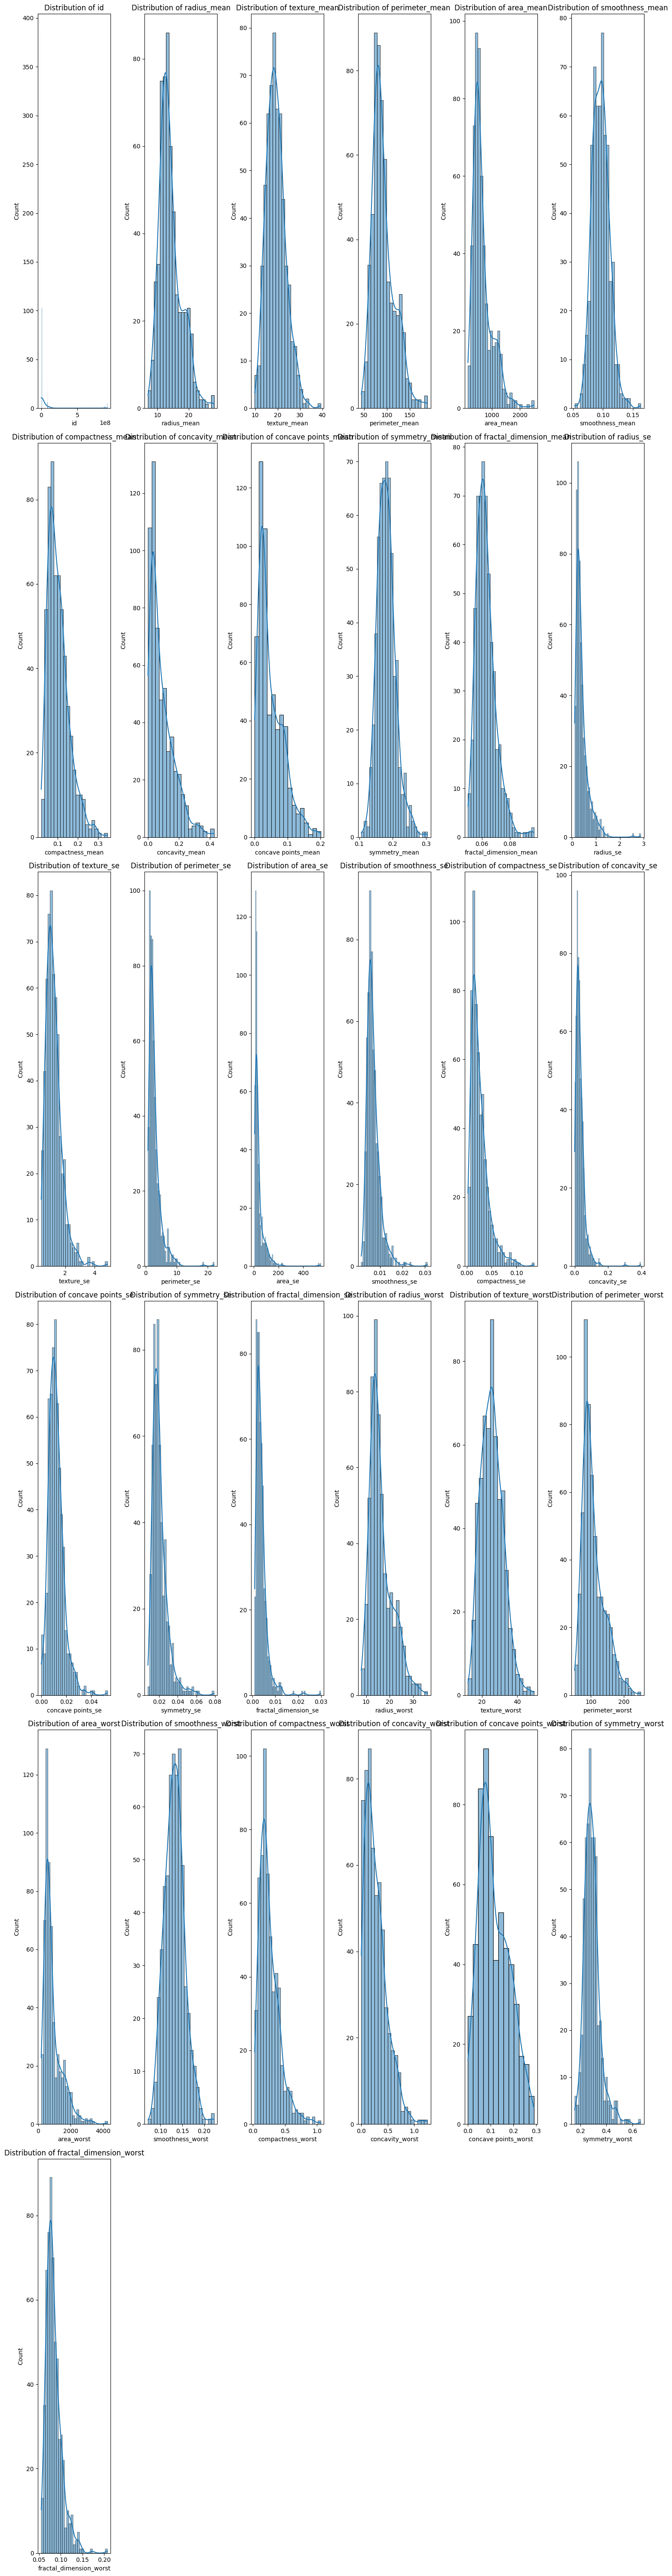

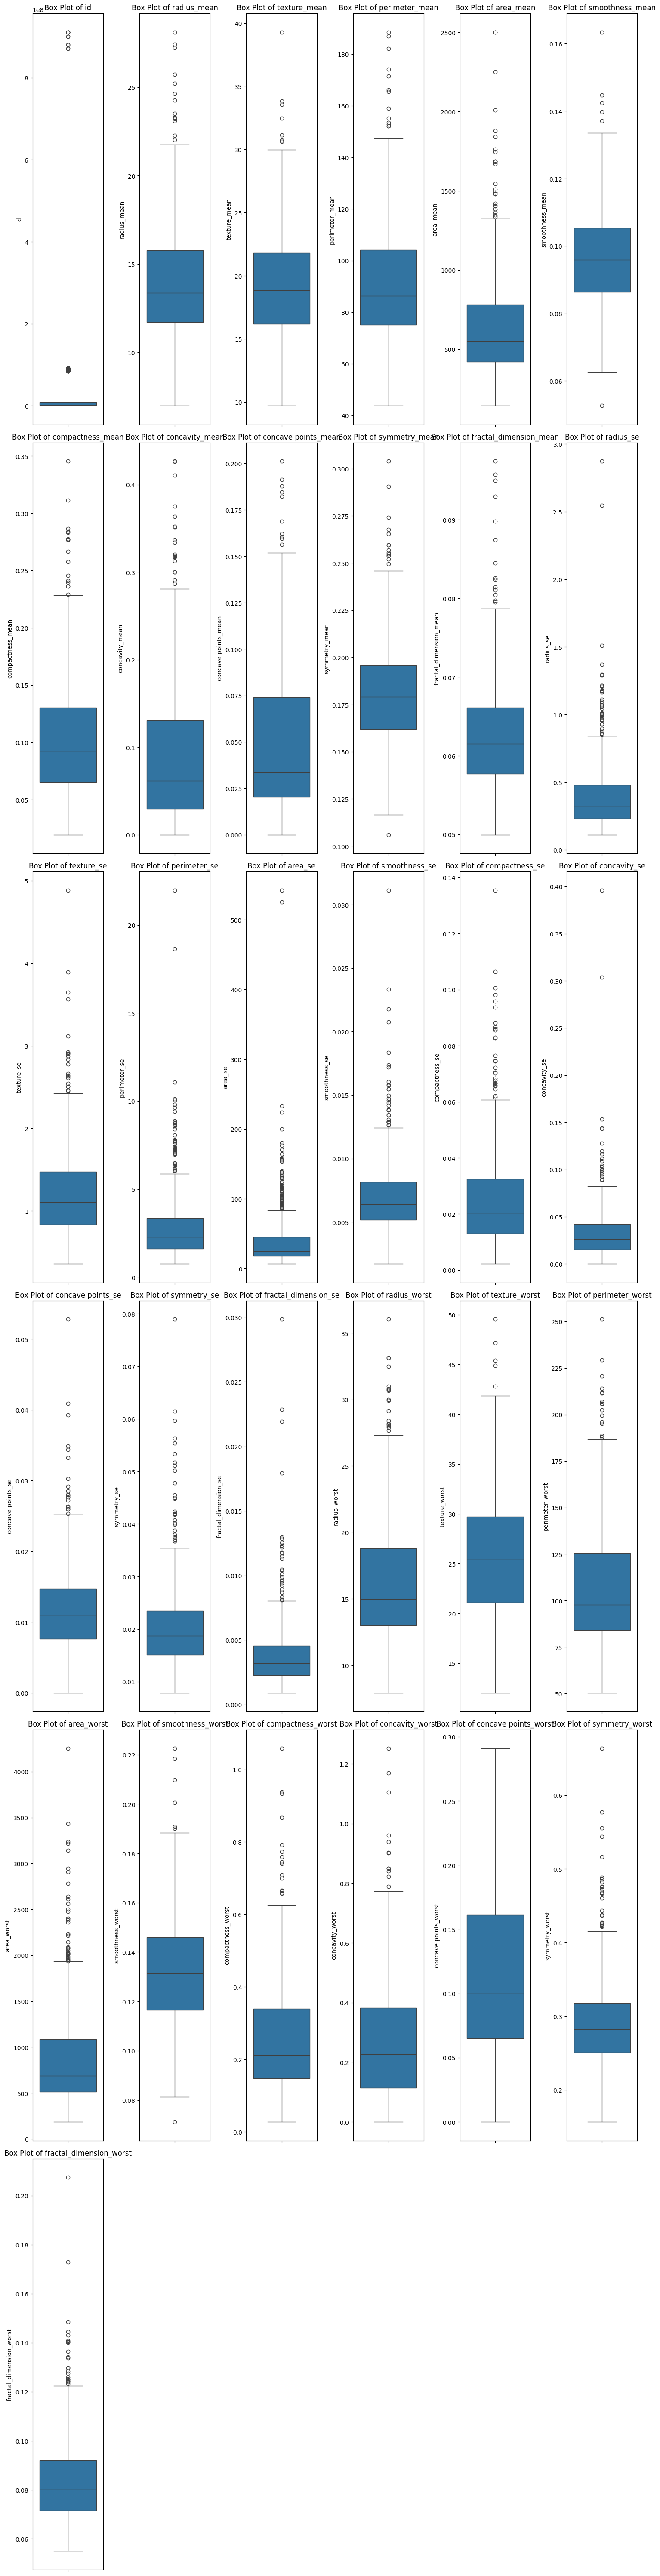

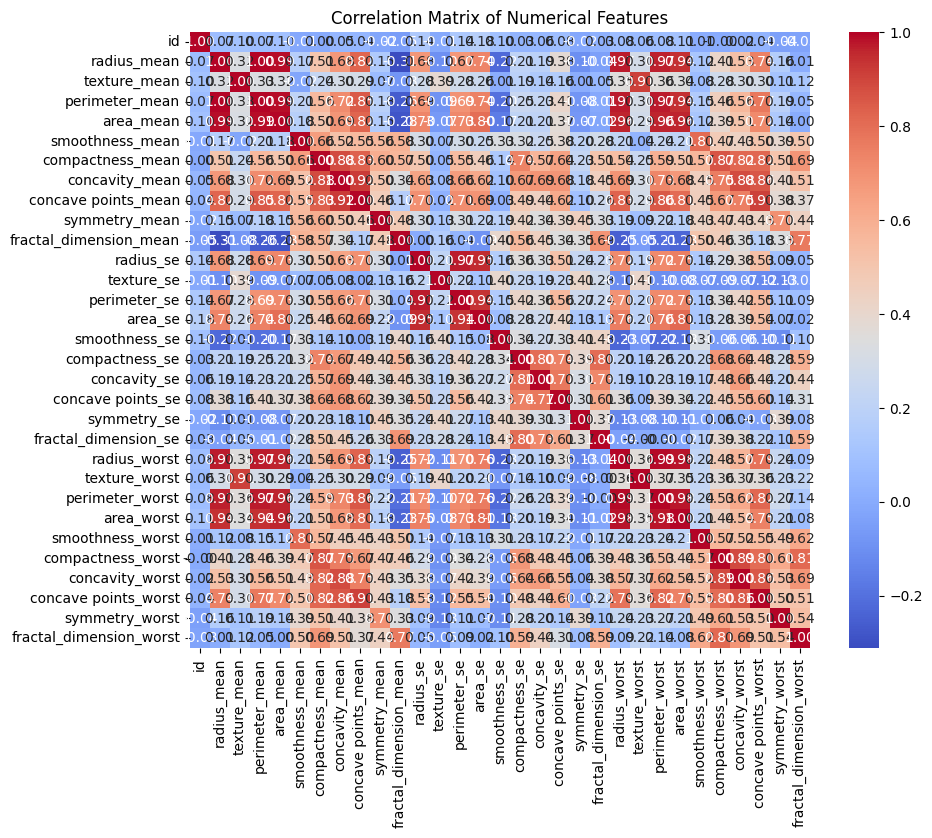


EDA for Categorical Features (data_cat):


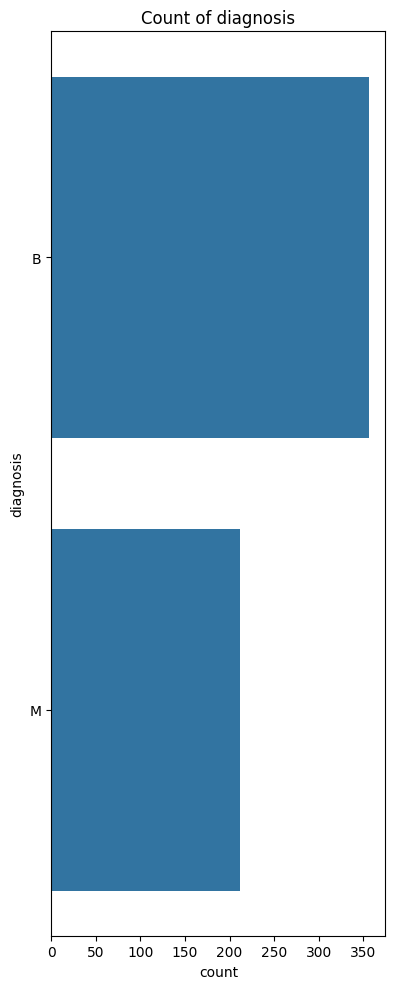

In [31]:
print('EDA for Numerical Features (data_num):')

eda_num = data_dropped.select_dtypes(exclude=object)
eda_cat = data_dropped.select_dtypes(include=object)

# Histograms for numerical features
plt.figure(figsize=(15, 60)) # Increased figure height to accommodate more subplots
rows = 6
cols = 6
for i, column in enumerate(eda_num.columns):
    plt.subplot(rows, cols, i + 1) # Adjust subplot grid based on number of columns
    sns.histplot(eda_num[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.tight_layout()
plt.show()

# Box plots for numerical features
plt.figure(figsize=(15, 60)) # Increased figure height to accommodate more subplots
for i, column in enumerate(eda_num.columns):
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(y=eda_num[column])
    plt.title(f'Box Plot of {column}')
    plt.tight_layout()
plt.show()

# Correlation Matrix for numerical features
plt.figure(figsize=(10, 8))
sns.heatmap(eda_num.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()


print('\nEDA for Categorical Features (data_cat):')
# Count plots for categorical features
plt.figure(figsize=(25, 10))
for i, column in enumerate(eda_cat.columns):
    plt.subplot(1, 7, i + 1) # Adjust subplot grid based on number of columns
    sns.countplot(y=eda_cat[column], order = eda_cat[column].value_counts().index)
    plt.title(f'Count of {column}')
    plt.tight_layout()
plt.show()

In [47]:
data_dropped['diagnosis'] = data_dropped['diagnosis'].map({'M': 1, 'B': 0})
data_dropped['diagnosis'].value_counts()

,count
diagnosis,
0,357
1,212


In [48]:
X = data_dropped.drop('diagnosis', axis=1)
y = data_dropped['diagnosis']

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [44]:
! pip install xgboost

In [50]:
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

models = [
    LogisticRegression(random_state=42, max_iter=1000),
    KNeighborsClassifier(n_neighbors=1,   weights='uniform'),
    KNeighborsClassifier(n_neighbors=5,   weights='uniform'),
    KNeighborsClassifier(n_neighbors=10,  weights='uniform'),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=3, random_state=42),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=10, random_state=42),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=30, random_state=42),
    DecisionTreeClassifier(max_leaf_nodes=3, random_state=42),
    DecisionTreeClassifier(max_leaf_nodes=10, random_state=42),
    DecisionTreeClassifier(max_leaf_nodes=30, random_state=42),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=3, random_state=42),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=10, random_state=42),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=30, random_state=42),
    xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_leaves=3, random_state=42),
    xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_leaves=10, random_state=42),
    xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_leaves=30, random_state=42),
    AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
]

Stratified Kfold cross validation for ML model

In [51]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import StratifiedKFold, cross_val_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import pandas as pd

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
for model in models:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(k_neighbors=10, random_state=42)),
        ('clf', model),
    ])
    # raw X_train / y_train — NOT X_train_res
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=kf, scoring='f1')
    cv_scores = pd.DataFrame(cv_scores)

    print(model)
    print(cv_scores.describe().T)
    print()

LogisticRegression(max_iter=1000, random_state=42)
   count      mean       std       min       25%       50%       75%  max
0    5.0  0.961623  0.026945  0.925373  0.956522  0.956522  0.969697  1.0

KNeighborsClassifier(n_neighbors=1)
   count      mean       std       min       25%       50%     75%       max
0    5.0  0.937858  0.027995  0.911765  0.925373  0.929577  0.9375  0.985075

KNeighborsClassifier()
   count      mean       std       min       25%       50%       75%       max
0    5.0  0.961278  0.022751  0.925373  0.955224  0.969697  0.970588  0.985507

KNeighborsClassifier(n_neighbors=10)
   count      mean       std       min       25%       50%       75%       max
0    5.0  0.961098  0.013781  0.939394  0.955224  0.969697  0.970588  0.970588

RandomForestClassifier(max_leaf_nodes=3, random_state=42)
   count      mean       std       min       25%       50%       75%       max
0    5.0  0.910105  0.025778  0.878788  0.891892  0.909091  0.929577  0.941176

RandomForestCl

LogisticRegression(max_iter=1000, random_state=42)
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        72
           1       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



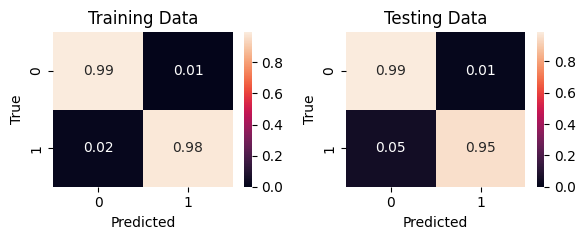

KNeighborsClassifier(n_neighbors=1)
              precision    recall  f1-score   support

           0       0.95      0.96      0.95        72
           1       0.93      0.90      0.92        42

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



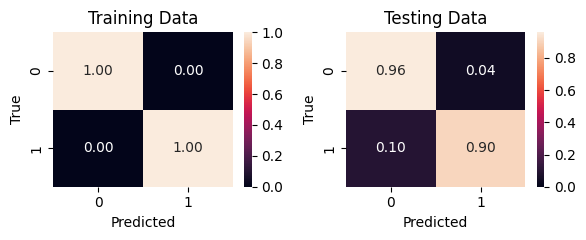

KNeighborsClassifier()
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



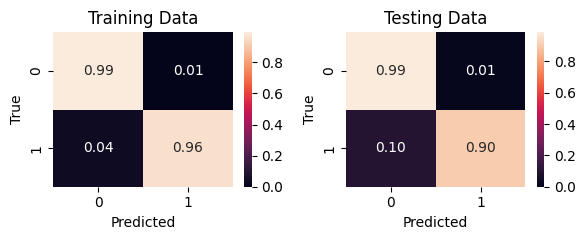

KNeighborsClassifier(n_neighbors=10)
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



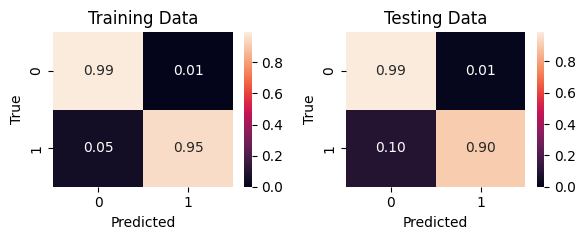

RandomForestClassifier(max_leaf_nodes=3, random_state=42)
              precision    recall  f1-score   support

           0       0.93      0.97      0.95        72
           1       0.95      0.88      0.91        42

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



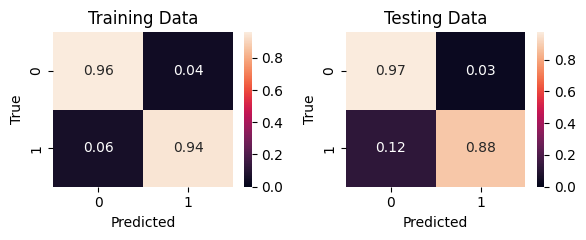

RandomForestClassifier(max_leaf_nodes=10, random_state=42)
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        72
           1       1.00      0.88      0.94        42

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114



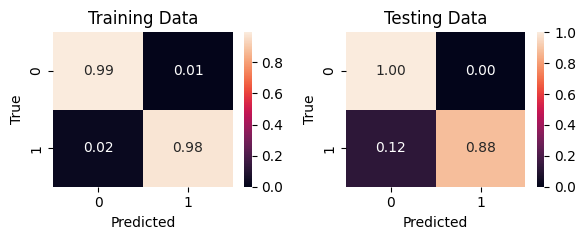

RandomForestClassifier(max_leaf_nodes=30, random_state=42)
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



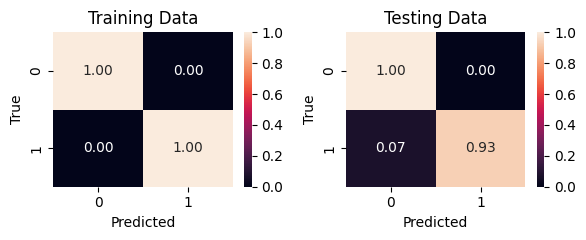

DecisionTreeClassifier(max_leaf_nodes=3, random_state=42)
              precision    recall  f1-score   support

           0       0.93      0.97      0.95        72
           1       0.95      0.88      0.91        42

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



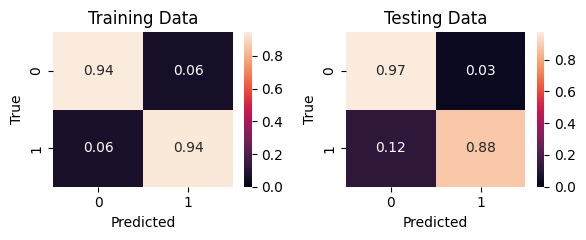

DecisionTreeClassifier(max_leaf_nodes=10, random_state=42)
              precision    recall  f1-score   support

           0       0.92      0.99      0.95        72
           1       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



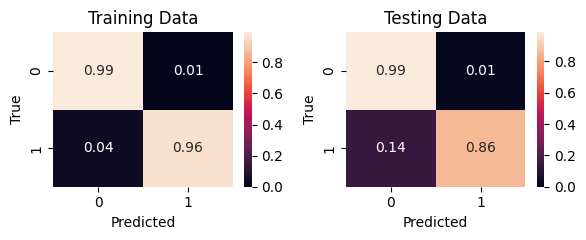

DecisionTreeClassifier(max_leaf_nodes=30, random_state=42)
              precision    recall  f1-score   support

           0       0.93      0.97      0.95        72
           1       0.95      0.88      0.91        42

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



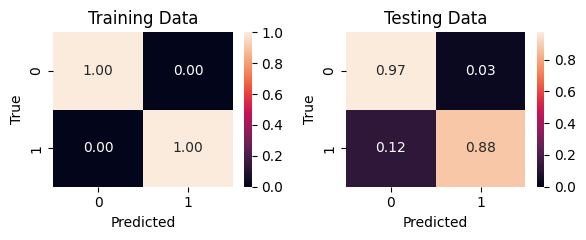

GradientBoostingClassifier(max_leaf_nodes=3, random_state=42)
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



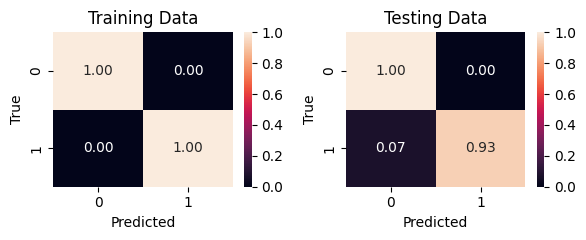

GradientBoostingClassifier(max_leaf_nodes=10, random_state=42)
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



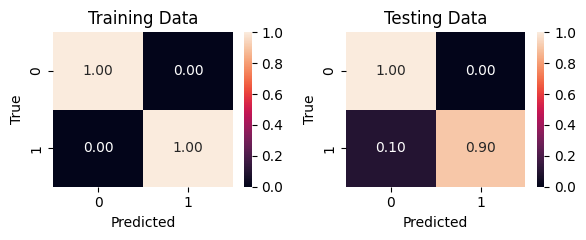

GradientBoostingClassifier(max_leaf_nodes=30, random_state=42)
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



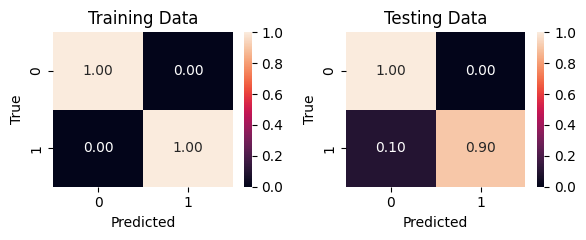

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=3, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        72
           1       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99    

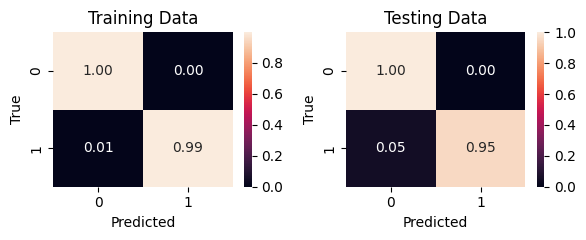

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=10, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98   

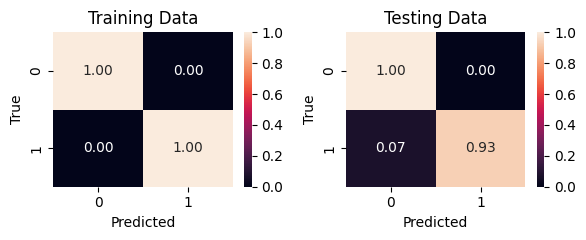

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=30, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98   

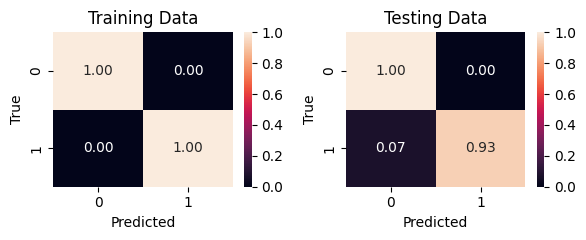

AdaBoostClassifier(learning_rate=0.1, n_estimators=100, random_state=42)
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



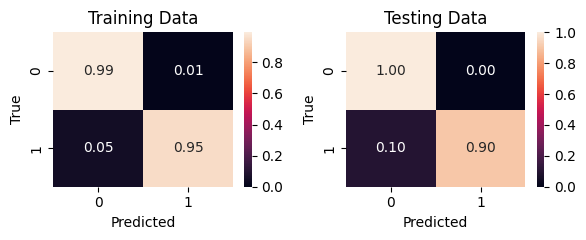

In [52]:
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

for m in models:
    # wrap this model in the pipeline
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(k_neighbors=10, random_state=42)),
        ('clf',    m),
    ])
    pipe.fit(X_train, y_train)          # scales + SMOTEs internally, then fits m

    print(m)
    y_train_pred = pipe.predict(X_train)   # real rows, scaled, not SMOTEd
    y_test_pred  = pipe.predict(X_test)

    print(classification_report(y_test, y_test_pred))

    conf_matrix_train = confusion_matrix(y_train, y_train_pred).astype(float)
    conf_matrix_test  = confusion_matrix(y_test,  y_test_pred).astype(float)

    for i in range(conf_matrix_train.shape[0]):
        conf_matrix_train[i,:] = conf_matrix_train[i,:] / conf_matrix_train[i,:].sum()
        conf_matrix_test[i,:]  = conf_matrix_test[i,:] / conf_matrix_test[i,:].sum()
    # end

    # Create subplots for side-by-side visualization
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6, 2.5))

    # Plot confusion matrix for training data
    sns.heatmap(conf_matrix_train, annot=True, vmin=0, fmt='.2f', ax=axes[0])
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")
    axes[0].set_title("Training Data")

    # Plot confusion matrix for test data
    sns.heatmap(conf_matrix_test, annot=True, vmin=0, fmt='.2f', ax=axes[1])
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")
    axes[1].set_title("Testing Data")

    # Show the plots
    plt.tight_layout()
    plt.show()
# end

ROC Curve

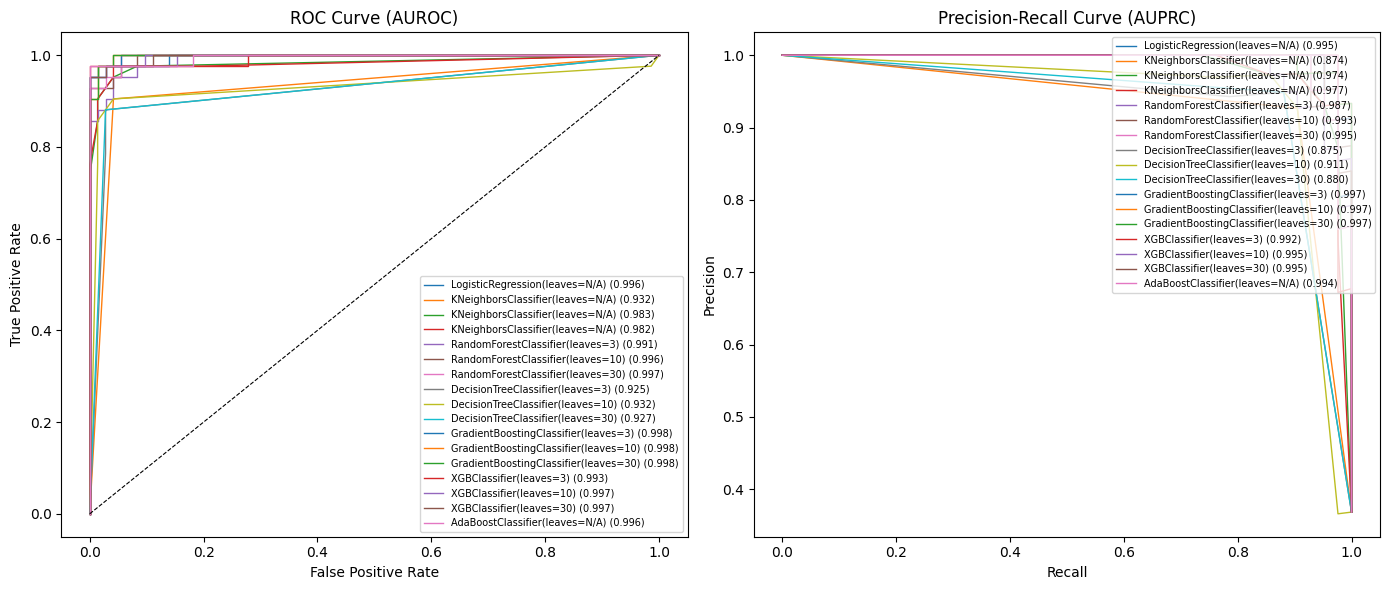

In [53]:
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_curve, roc_auc_score, matthews_corrcoef
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Create a list to store pipelines for consistent evaluation
pipelines = []
for m in models:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(k_neighbors=10, random_state=42)),
        ('clf',    m),
    ])
    pipe.fit(X_train, y_train) # Fit each pipeline on the original X_train, y_train
    model_name = f"{m.__class__.__name__}(leaves={getattr(m, 'max_leaf_nodes', getattr(m, 'max_leaves', 'N/A'))})"
    pipelines.append({'pipe': pipe, 'name': model_name})

for pipeline_result in pipelines:
    pipe = pipeline_result['pipe']
    name = pipeline_result['name']

    # Ensure the classifier in the pipeline has predict_proba
    if hasattr(pipe.named_steps['clf'], 'predict_proba'):
        y_prob = pipe.predict_proba(X_test)[:, 1]
    else:
        # Handle models without predict_proba if necessary, e.g., default to 0.5 or raise error
        y_prob = [0.5] * len(y_test) # Placeholder

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auroc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f"{name} ({auroc:.3f})", linewidth=1)

    # PR curve
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    axes[1].plot(recall_vals, precision_vals, label=f"{name} ({ap:.3f})", linewidth=1)

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
axes[0].set(xlabel='False Positive Rate', ylabel='True Positive Rate',
            title='ROC Curve (AUROC)')
axes[0].legend(fontsize=7, loc='lower right')

axes[1].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall Curve (AUPRC)')
axes[1].legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.show()

In [61]:
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score

# Select the fitted pipeline for Logistic Regression (index 0 in the 'pipelines' list)
# You can change the index to evaluate other models. For example, to evaluate the first RandomForestClassifier (index 4 in 'models')
# you would need to find its corresponding pipeline in the 'pipelines' list.
# Looking at the 'pipelines' variable in the kernel state, LogisticRegression is at index 0.

# Assuming `pipelines` list is available from the previous cell's execution
# If you want to evaluate a different model, find its corresponding index in `pipelines`
selected_pipeline_result = pipelines[0] # Example: LogisticRegression
model_name = selected_pipeline_result['name']
fitted_pipe = selected_pipeline_result['pipe']

y_score = fitted_pipe.predict_proba(X_test)[:, 1]
auprc = average_precision_score(y_test, y_score)
auroc = roc_auc_score(y_test, y_score)

print(f"Model: {model_name}")
print("AUPRC:", auprc)
print("AUROC:", auroc)


Model: KNeighborsClassifier(leaves=N/A)
AUPRC: 0.8736475334678159
AUROC: 0.9315476190476191


ML models classification report and confusion matrix


Model: LogisticRegression(leaves=N/A)
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        72
           1       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



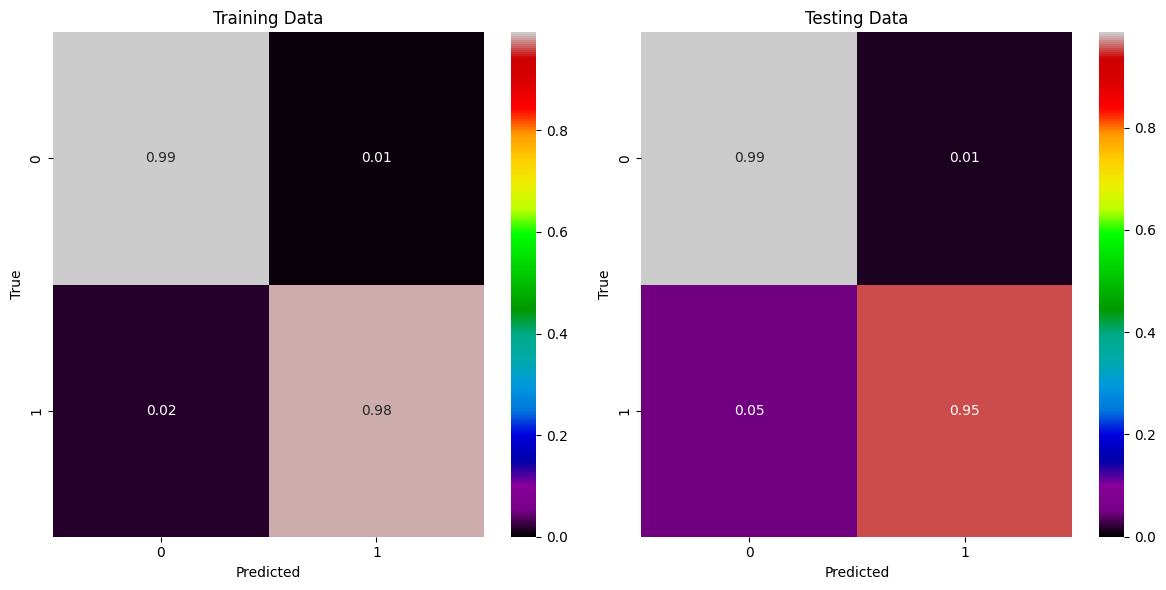


Model: KNeighborsClassifier(leaves=N/A)
              precision    recall  f1-score   support

           0       0.95      0.96      0.95        72
           1       0.93      0.90      0.92        42

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



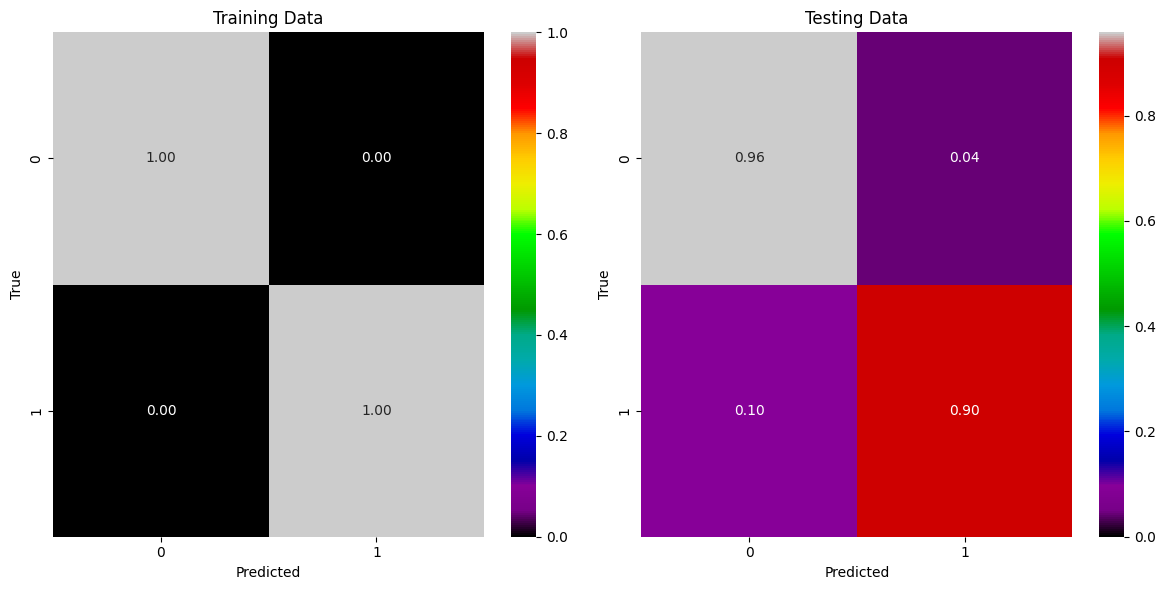


Model: KNeighborsClassifier(leaves=N/A)
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



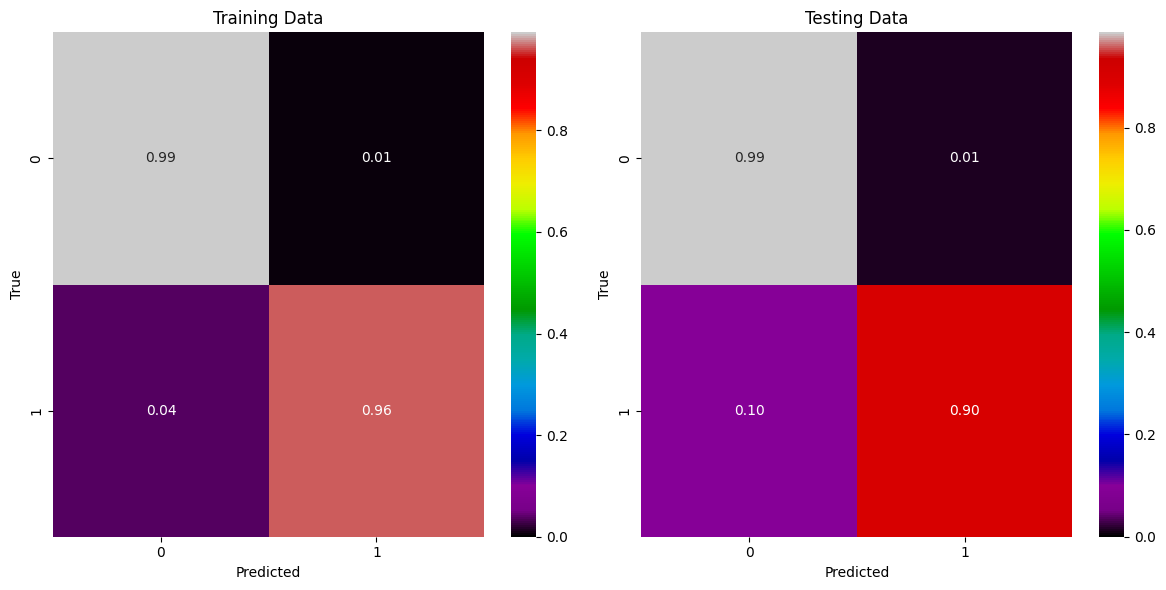


Model: KNeighborsClassifier(leaves=N/A)
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



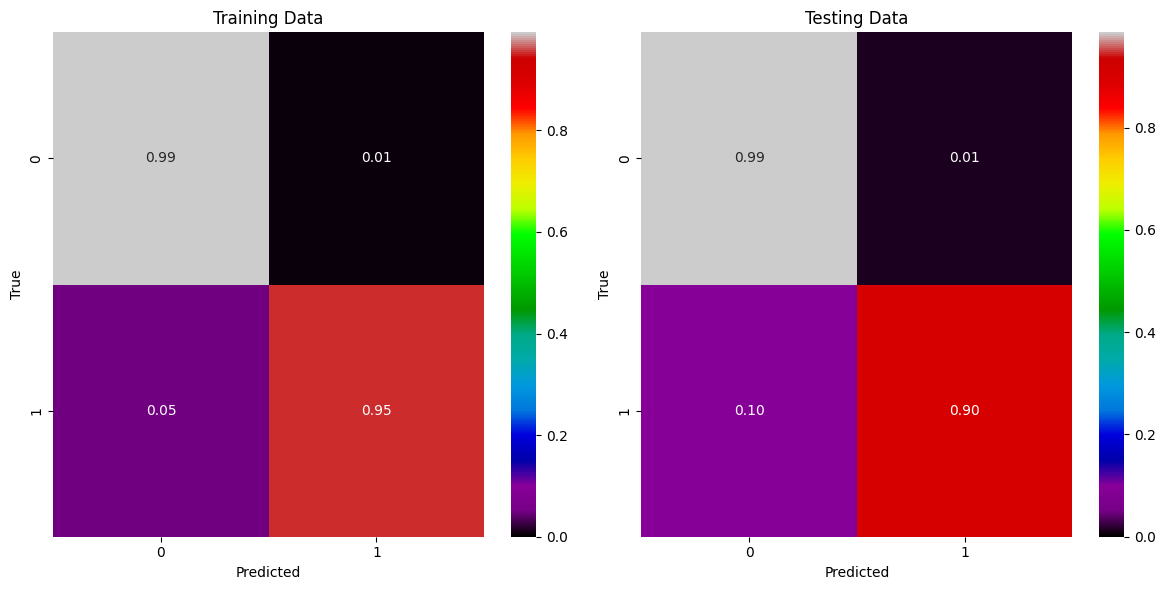


Model: RandomForestClassifier(leaves=3)
              precision    recall  f1-score   support

           0       0.93      0.97      0.95        72
           1       0.95      0.88      0.91        42

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



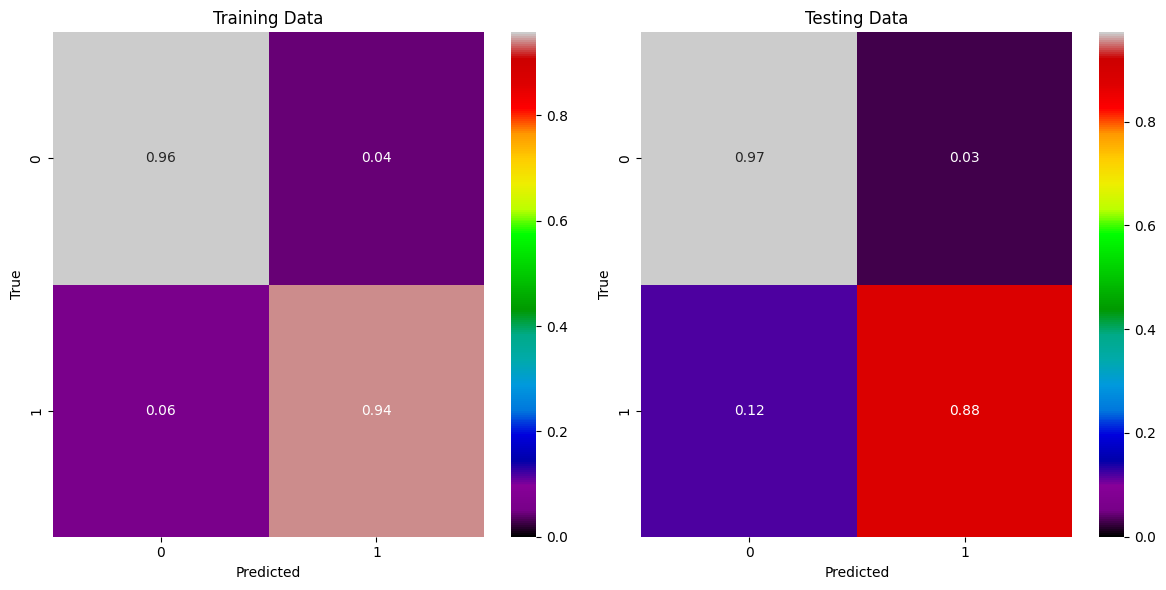


Model: RandomForestClassifier(leaves=10)
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        72
           1       1.00      0.88      0.94        42

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114



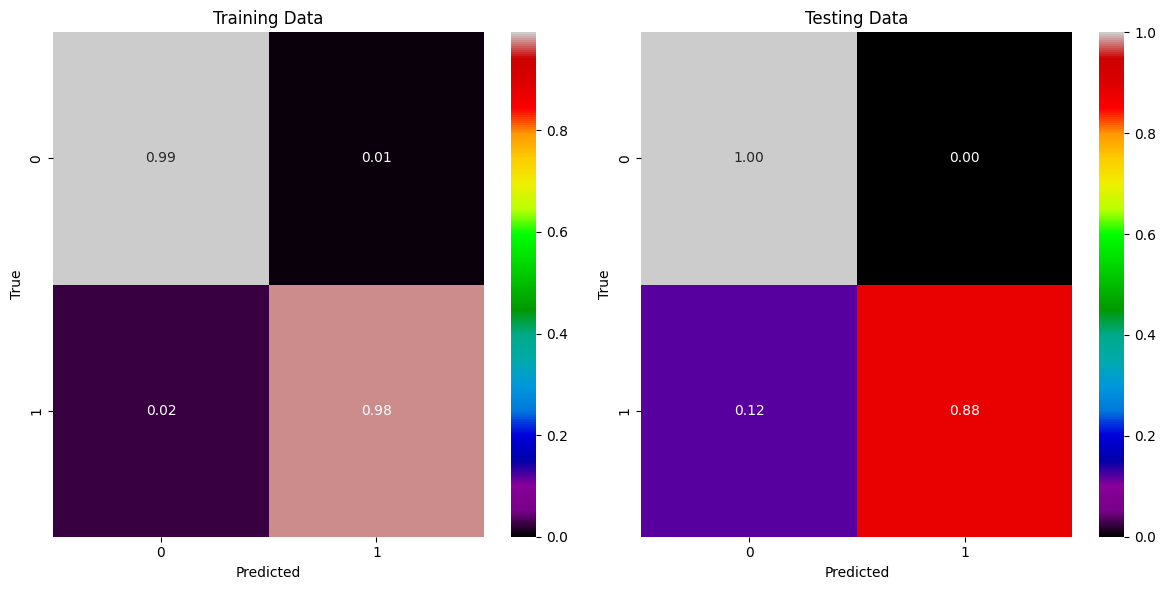


Model: RandomForestClassifier(leaves=30)
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



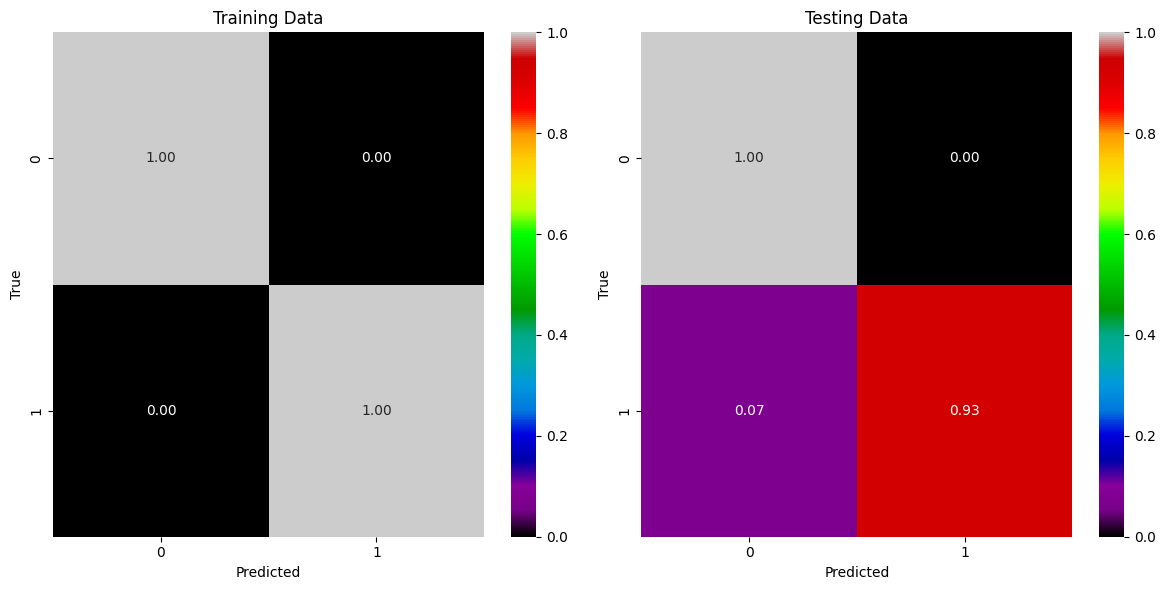


Model: DecisionTreeClassifier(leaves=3)
              precision    recall  f1-score   support

           0       0.93      0.97      0.95        72
           1       0.95      0.88      0.91        42

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



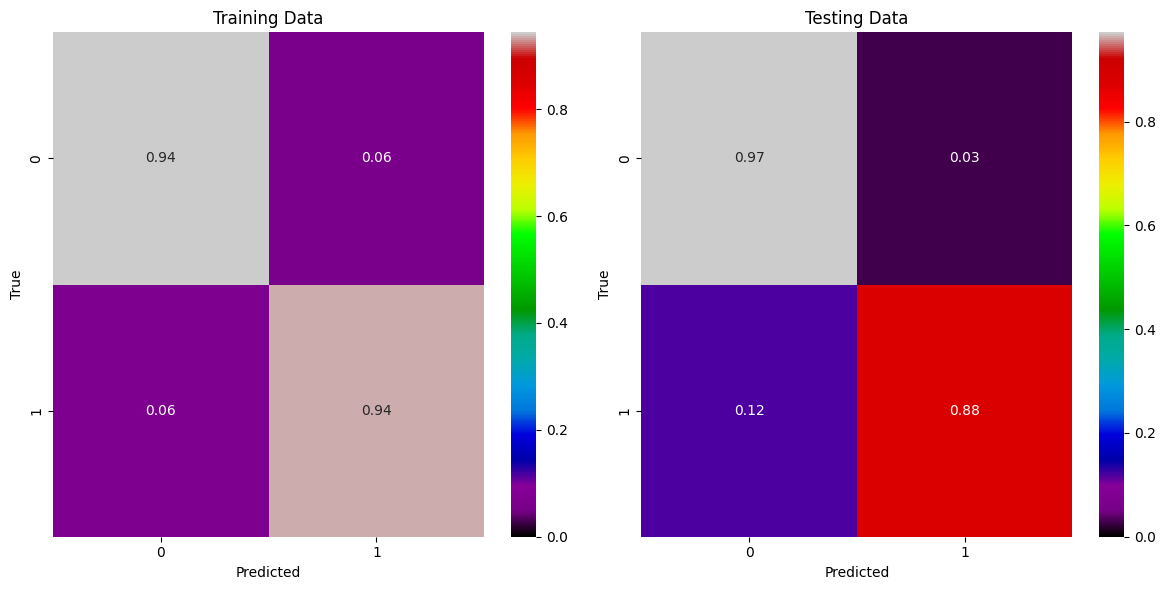


Model: DecisionTreeClassifier(leaves=10)
              precision    recall  f1-score   support

           0       0.92      0.99      0.95        72
           1       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



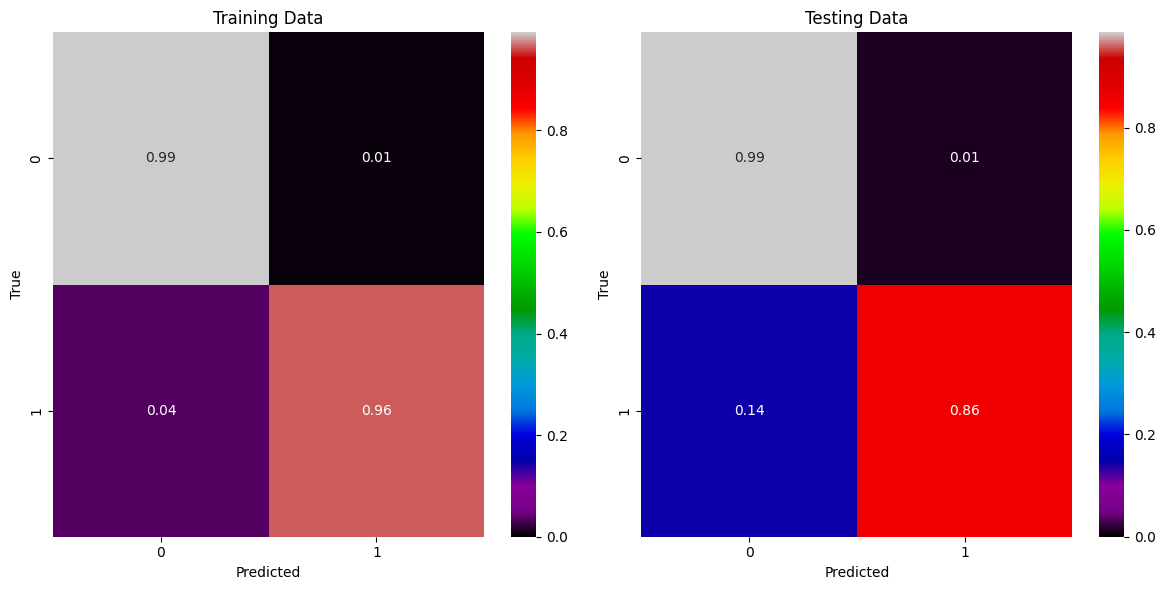


Model: DecisionTreeClassifier(leaves=30)
              precision    recall  f1-score   support

           0       0.93      0.97      0.95        72
           1       0.95      0.88      0.91        42

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



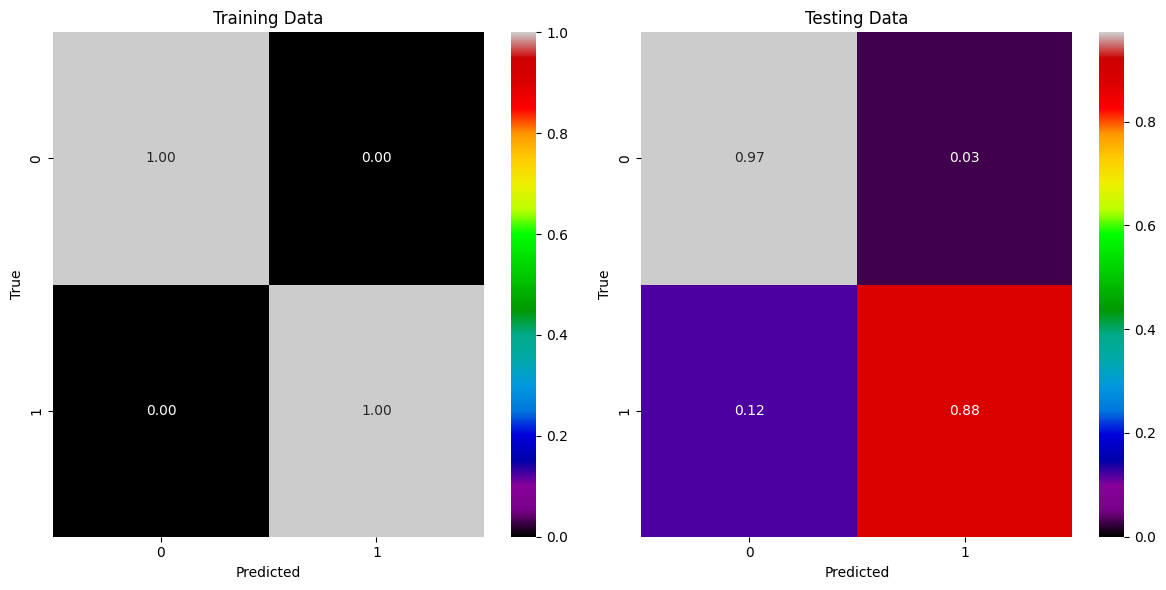


Model: GradientBoostingClassifier(leaves=3)
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



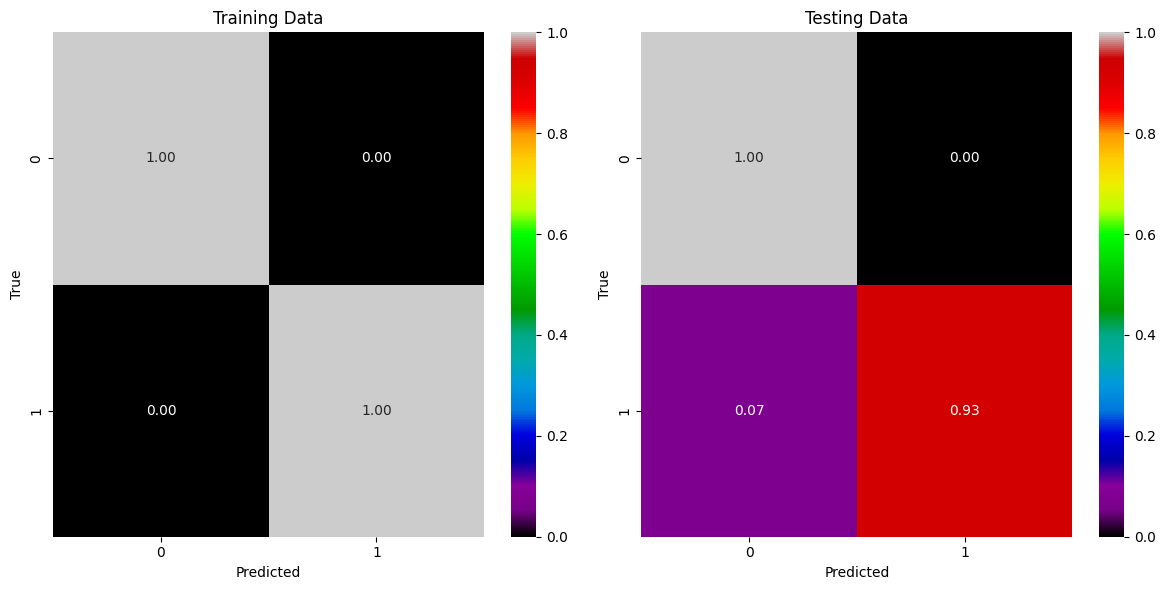


Model: GradientBoostingClassifier(leaves=10)
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



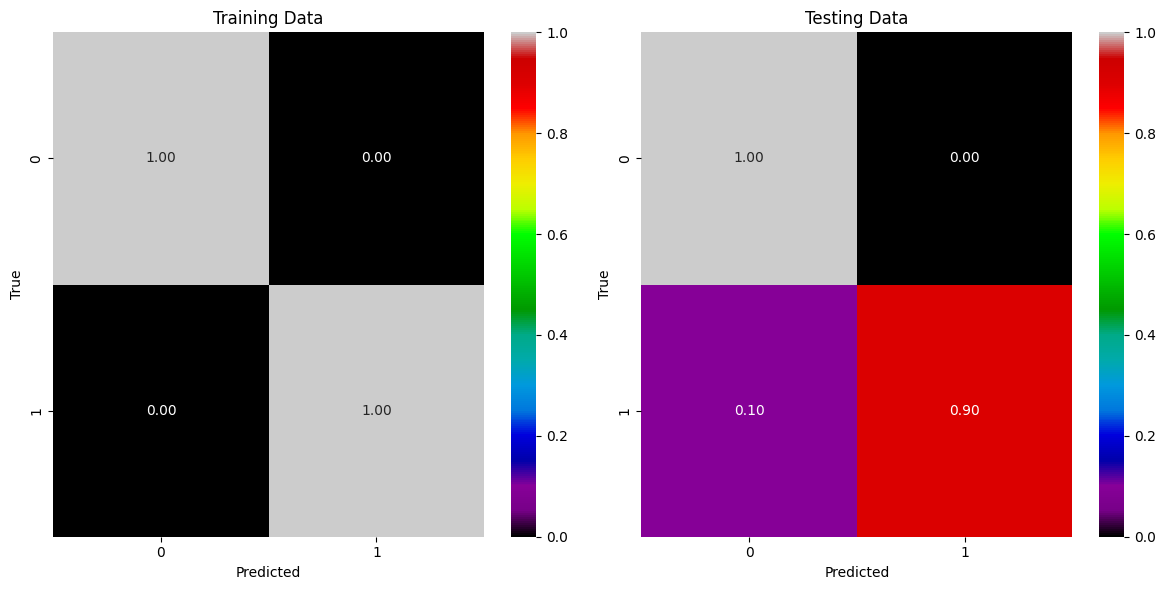


Model: GradientBoostingClassifier(leaves=30)
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



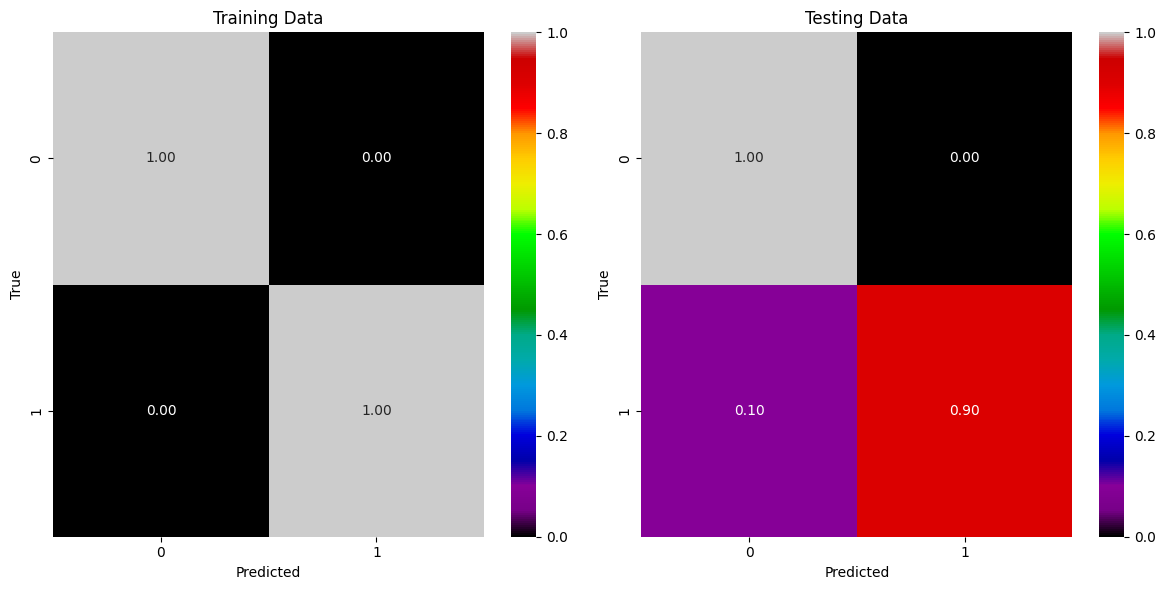


Model: XGBClassifier(leaves=3)
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        72
           1       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



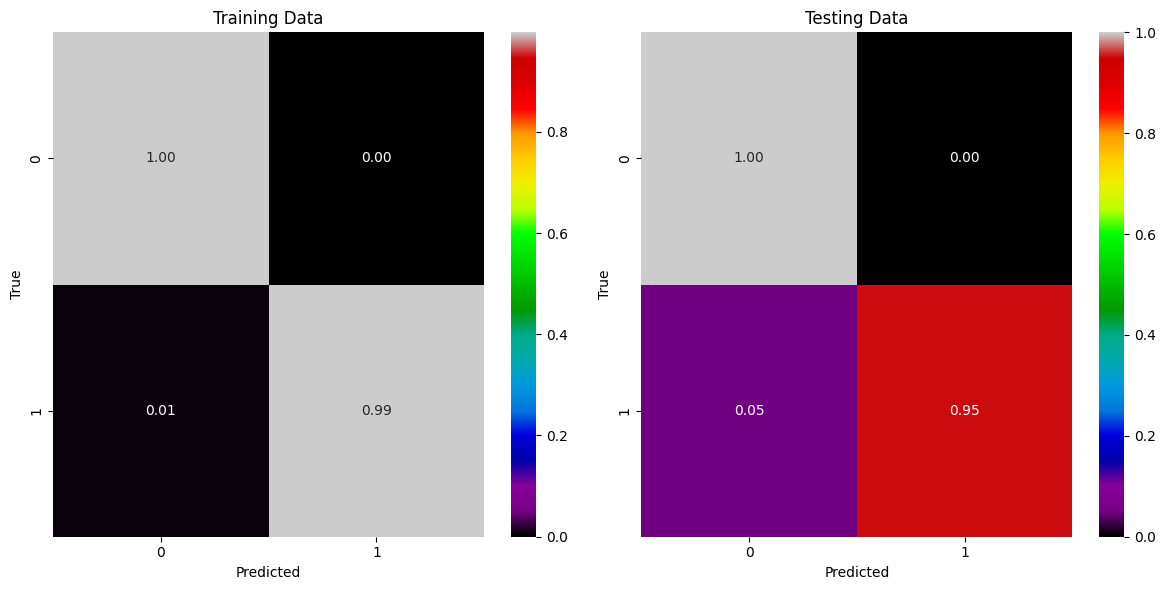


Model: XGBClassifier(leaves=10)
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



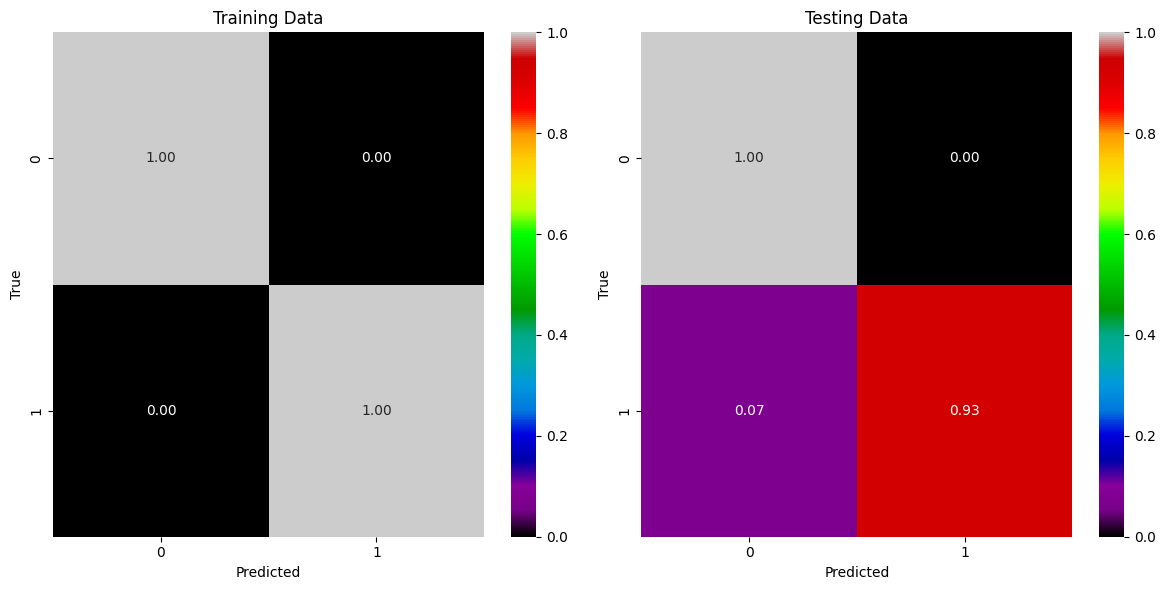


Model: XGBClassifier(leaves=30)
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



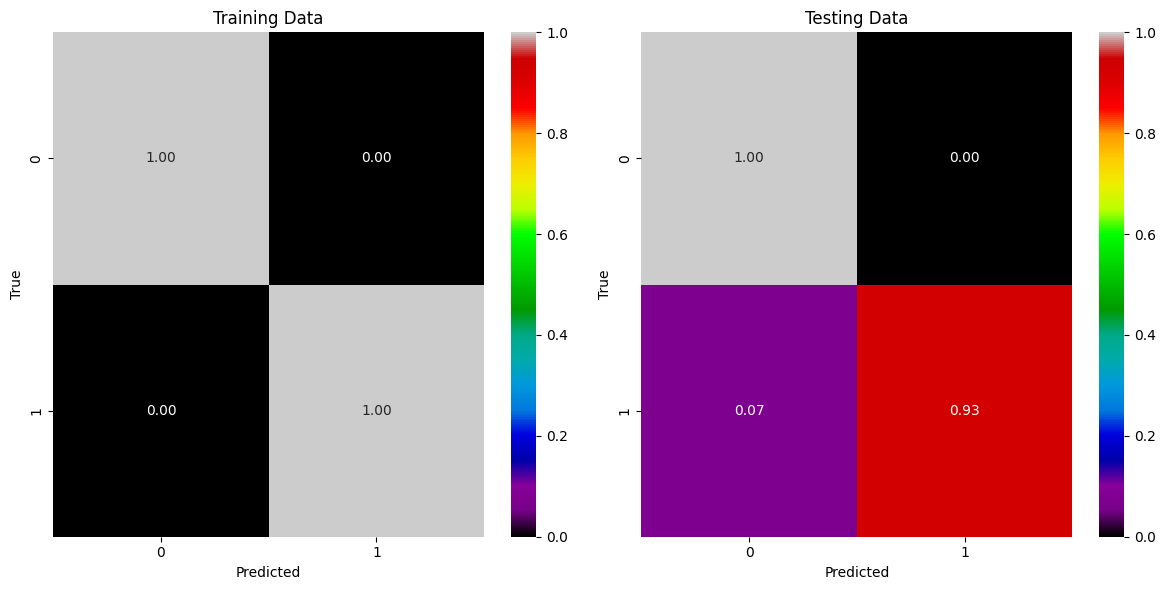


Model: AdaBoostClassifier(leaves=N/A)
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



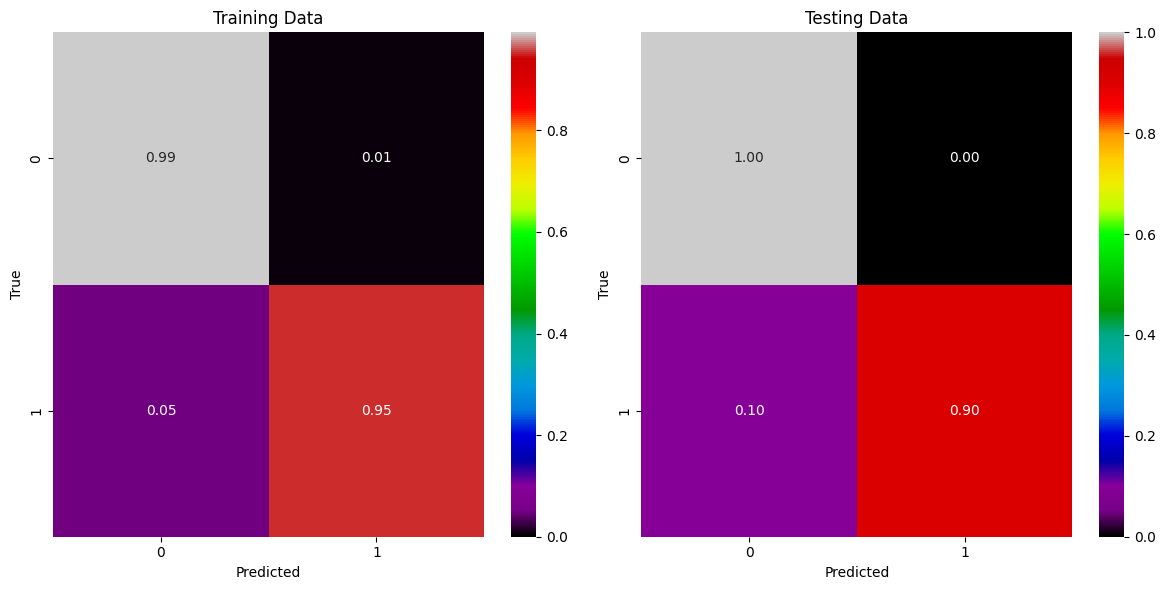


=== Model Comparison (sorted by AUPRC) ===
                                Model    AUPRC    AUROC      MCC       F1
 GradientBoostingClassifier(leaves=3) 0.996822 0.998016 0.944155 0.962963
GradientBoostingClassifier(leaves=30) 0.996670 0.998016 0.925820 0.950000
GradientBoostingClassifier(leaves=10) 0.996670 0.998016 0.925820 0.950000
             XGBClassifier(leaves=10) 0.995491 0.997024 0.944155 0.962963
             XGBClassifier(leaves=30) 0.995083 0.996693 0.944155 0.962963
       LogisticRegression(leaves=N/A) 0.994854 0.996362 0.943340 0.963855
    RandomForestClassifier(leaves=30) 0.994679 0.996693 0.944155 0.962963
       AdaBoostClassifier(leaves=N/A) 0.994372 0.995701 0.925820 0.950000
    RandomForestClassifier(leaves=10) 0.993246 0.995701 0.907605 0.936709
              XGBClassifier(leaves=3) 0.992320 0.993386 0.962622 0.975610
     RandomForestClassifier(leaves=3) 0.986840 0.991402 0.867493 0.913580
     KNeighborsClassifier(leaves=N/A) 0.976721 0.982143 0.905824 0.9

In [62]:
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score, roc_auc_score, matthews_corrcoef, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

results = []

for i, m in enumerate(models):
    # Wrap the model in a pipeline with StandardScaler and SMOTE
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(k_neighbors=10, random_state=42)),
        ('clf', m),
    ])

    pipe.fit(X_train, y_train) # Fit the pipeline on original X_train, y_train

    # Make predictions using the pipeline
    y_train_pred = pipe.predict(X_train)
    y_test_pred = pipe.predict(X_test)

    # Calculate y_prob for the current model
    # Ensure the classifier in the pipeline has predict_proba
    if hasattr(pipe.named_steps['clf'], 'predict_proba'):
        y_prob = pipe.predict_proba(X_test)[:, 1]
    else:
        # Handle models without predict_proba if necessary, e.g., default to 0.5 or raise error
        y_prob = [0.5] * len(y_test) # Placeholder, adjust as needed

    auprc = average_precision_score(y_test, y_prob)
    auroc = roc_auc_score(y_test, y_prob)
    mcc   = matthews_corrcoef(y_test, y_test_pred)
    f1    = f1_score(y_test, y_test_pred)
    name  = f"{m.__class__.__name__}(leaves={getattr(m, 'max_leaf_nodes', getattr(m, 'max_leaves', 'N/A'))})"

    results.append({
        'Model': name,
        'AUPRC': auprc,
        'AUROC': auroc,
        'MCC':   mcc,
        'F1':    f1,
    })

    print(f"\n{'='*60}")
    print(f"Model: {name}")
    print(classification_report(y_test, y_test_pred))

    # Compute confusion matrices
    conf_matrix_train = confusion_matrix(y_train, y_train_pred)
    conf_matrix_test = confusion_matrix(y_test, y_test_pred)

    conf_matrix_train = conf_matrix_train.astype(float)
    conf_matrix_test  = conf_matrix_test.astype(float)
    for row_idx in range(conf_matrix_train.shape[0]):
        if conf_matrix_train[row_idx,:].sum() > 0:
            conf_matrix_train[row_idx,:] = conf_matrix_train[row_idx,:] / conf_matrix_train[row_idx,:].sum()
        if conf_matrix_test[row_idx,:].sum() > 0:
            conf_matrix_test[row_idx,:]  = conf_matrix_test[row_idx,:] / conf_matrix_test[row_idx,:].sum()

    # Create subplots for side-by-side visualization
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

    # Plot confusion matrix for training data
    sns.heatmap(conf_matrix_train, annot=True, vmin=0, fmt='.2f', ax=axes[0], cmap='nipy_spectral')
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")
    axes[0].set_title("Training Data")

    # Plot confusion matrix for test data
    sns.heatmap(conf_matrix_test, annot=True, vmin=0, fmt='.2f', ax=axes[1], cmap='nipy_spectral')
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")
    axes[1].set_title("Testing Data")

    plt.tight_layout()
    plt.show()

# --- Model comparison table ───────────────────────────────────────────────────
results_df = pd.DataFrame(results).sort_values('AUPRC', ascending=False).reset_index(drop=True)
print("\n=== Model Comparison (sorted by AUPRC) ===")
print(results_df.to_string(index=False))

SHAP for feature importance

In [63]:
! pip install SHAP

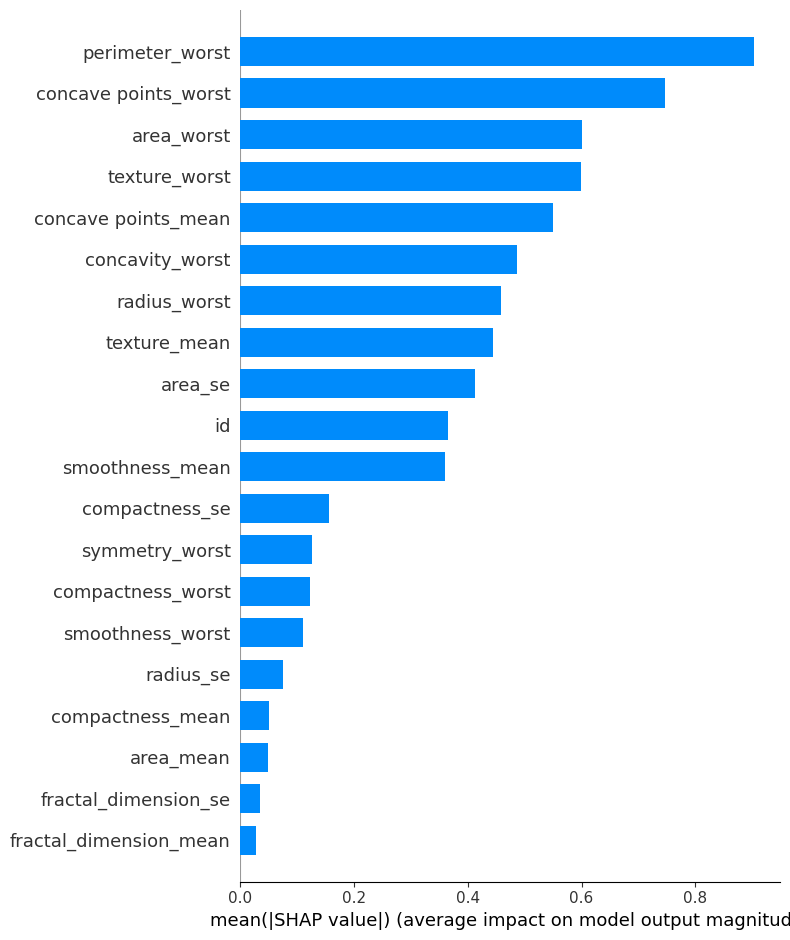

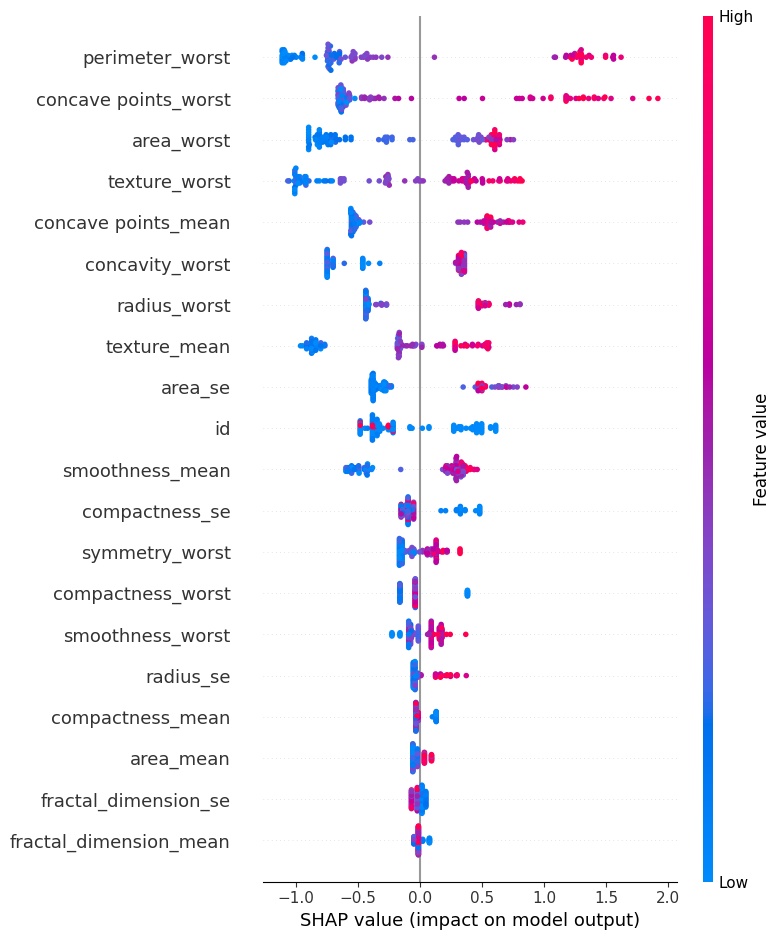

In [64]:
import shap

# Choose one of the trained models for explanation (e.g., the first XGBoost model)
# model_to_explain = models[9] # This is xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=3)
# Or, if you want to use the best performing model from your MLflow run, you would select it here.

# Let's refit the chosen model just to be safe, as the `models` list might not contain fitted versions
model_to_explain = models[13] # Changed to a tree-based model, e.g., xgb.XGBClassifier
model_to_explain.fit(X_train, y_train)

# Create a SHAP explainer
explainer = shap.TreeExplainer(model_to_explain)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Plot the SHAP summary plot (Feature Importance)
shap.summary_plot(shap_values, X_test, plot_type="bar")

# You can also get a more detailed summary plot
shap.summary_plot(shap_values, X_test)

#Deep Learning

Defining deep learning model architecture

In [65]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

dropout_rate = 0.1

n_classes = np.unique(y).shape[0]

# Create model
model = Sequential([
    Input(shape=X.shape[1:]),

    Dense(20, activation='relu'),
    BatchNormalization(),
    Dropout(dropout_rate),

    #Dense(20, activation='relu'),
    #BatchNormalization(),
    #Dropout(dropout_rate),

    #Dense(20, activation='relu'),
    #BatchNormalization(),
    #Dropout(dropout_rate),

    Dense(20, activation='relu'),

    Dense(n_classes, activation='softmax'),
])

# Define the optimizer with a custom learning rate
optimizer = Adam(learning_rate=0.005)

# Compile model
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=100,          # Stop after 5 epochs without improvement
    restore_best_weights=True  # Restore the best weights after stopping
)

# Display model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 20)             │            80 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            42 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,182 (4.62 KB)

 Trainable params: 1,142 (4.46 KB)

 Non-trainable params: 40 (160.00 B)

In [66]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# 1. carve a validation set OUT OF X_train (not X_test)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)

# 2. scale: fit on training part only
scaler = StandardScaler()
X_tr_s  = scaler.fit_transform(X_tr)
X_val_s = scaler.transform(X_val)     # transform only
X_test_s = scaler.transform(X_test)   # for the final evaluation later

# 3. SMOTE the scaled training part only
X_tr_res, y_tr_res = SMOTE(k_neighbors=10, random_state=42).fit_resample(X_tr_s, y_tr)

# 4. train on SMOTEd scaled data; validate on REAL scaled val set
history = model.fit(
    X_tr_res, y_tr_res,
    validation_data=(X_val_s, y_val),   # real, held-out — NOT X_test
    epochs=100, batch_size=256,
    callbacks=[early_stopping], verbose=1,
)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 537ms/step - accuracy: 0.3399 - loss: 1.5657 - val_accuracy: 0.3736 - val_loss: 1.0731
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 430ms/step - accuracy: 0.4956 - loss: 0.9842 - val_accuracy: 0.4176 - val_loss: 0.7713
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 385ms/step - accuracy: 0.6360 - loss: 0.6708 - val_accuracy: 0.5604 - val_loss: 0.5803
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 0.8158 - loss: 0.4622 - val_accuracy: 0.7802 - val_loss: 0.4572
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.8904 - loss: 0.3369 - val_accuracy: 0.8901 - val_loss: 0.3742
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.9276 - loss: 0.2591 - val_accuracy: 0.9231 - val_loss: 0.3117
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.9408 - loss: 0.2083 - val_accuracy: 0.9341 - val_loss: 0.2633
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - accuracy: 0.9583 - loss: 0.1734 - val_accuracy: 0.9451 - v

Confusion Matrix

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step 


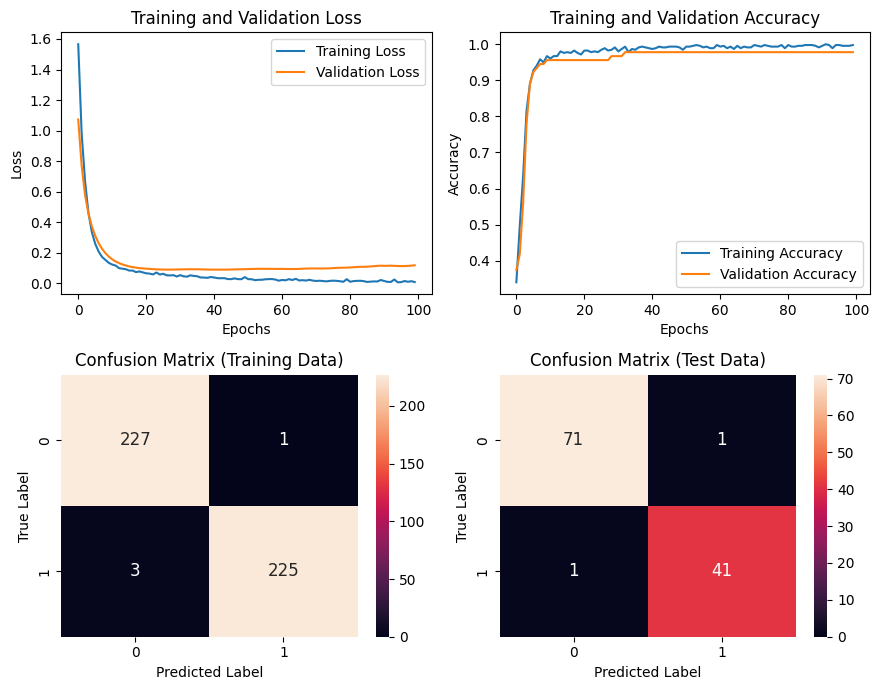

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99        72
           1       0.98      0.98      0.98        42

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [67]:
from sklearn.metrics import classification_report, confusion_matrix

# Predictions — use the SCALED test set (model was trained on scaled data)
y_train_pred = model.predict(X_tr_res).argmax(axis=1)
y_test_pred  = model.predict(X_test_s).argmax(axis=1)   # was X_test (raw) -> BUG

# Confusion matrices
cm_train = confusion_matrix(y_tr_res, y_train_pred)
cm_test  = confusion_matrix(y_test, y_test_pred)

# 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(9, 7))

axes[0, 0].plot(history.history['loss'], label='Training Loss')
axes[0, 0].plot(history.history['val_loss'], label='Validation Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].set_xlabel('Epochs'); axes[0, 0].set_ylabel('Loss'); axes[0, 0].legend()

axes[0, 1].plot(history.history['accuracy'], label='Training Accuracy')
axes[0, 1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0, 1].set_title('Training and Validation Accuracy')
axes[0, 1].set_xlabel('Epochs'); axes[0, 1].set_ylabel('Accuracy'); axes[0, 1].legend()

sns.heatmap(cm_train, annot=True, fmt='d', ax=axes[1, 0], vmin=0, annot_kws={"size": 12})
axes[1, 0].set_title('Confusion Matrix (Training Data)')
axes[1, 0].set_xlabel('Predicted Label'); axes[1, 0].set_ylabel('True Label')

sns.heatmap(cm_test, annot=True, fmt='d', ax=axes[1, 1], vmin=0, annot_kws={"size": 12})
axes[1, 1].set_title('Confusion Matrix (Test Data)')
axes[1, 1].set_xlabel('Predicted Label'); axes[1, 1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

print("Classification Report (Test Data):")
print(classification_report(y_test, y_test_pred))

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

models = [
    LogisticRegression(random_state=42, max_iter=1000),
    KNeighborsClassifier(n_neighbors=1,   weights='uniform'),
    KNeighborsClassifier(n_neighbors=5,   weights='uniform'),
    KNeighborsClassifier(n_neighbors=10,  weights='uniform'),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=3, random_state=42),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=10, random_state=42),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=30, random_state=42),
    DecisionTreeClassifier(max_leaf_nodes=3, random_state=42),
    DecisionTreeClassifier(max_leaf_nodes=10, random_state=42),
    DecisionTreeClassifier(max_leaf_nodes=30, random_state=42),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=3, random_state=42),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=10, random_state=42),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=30, random_state=42),
    xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_leaves=3, random_state=42),
    xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_leaves=10, random_state=42),
    xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_leaves=30, random_state=42),
    AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
]

Plotting Confusion matrix and classification report for Multiple ML model

LogisticRegression(max_iter=1000, random_state=42)
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        72
           1       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



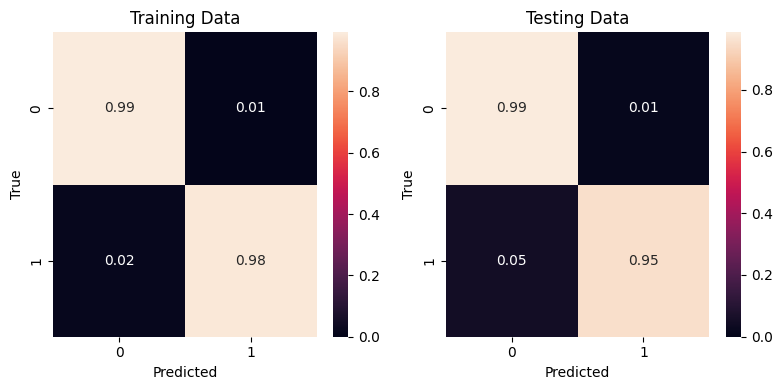

KNeighborsClassifier(n_neighbors=1)
              precision    recall  f1-score   support

           0       0.95      0.96      0.95        72
           1       0.93      0.90      0.92        42

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



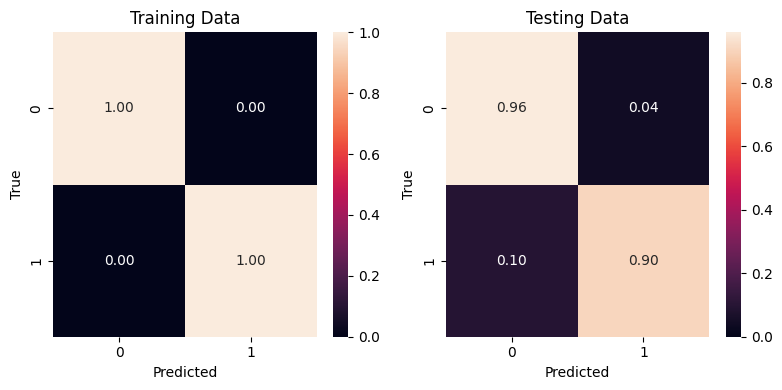

KNeighborsClassifier()
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



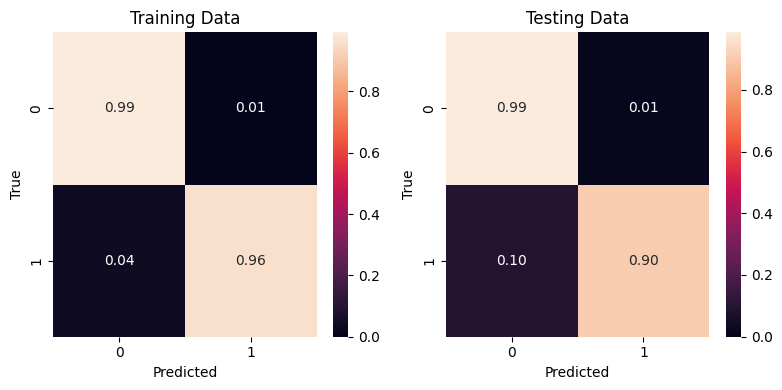

KNeighborsClassifier(n_neighbors=10)
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



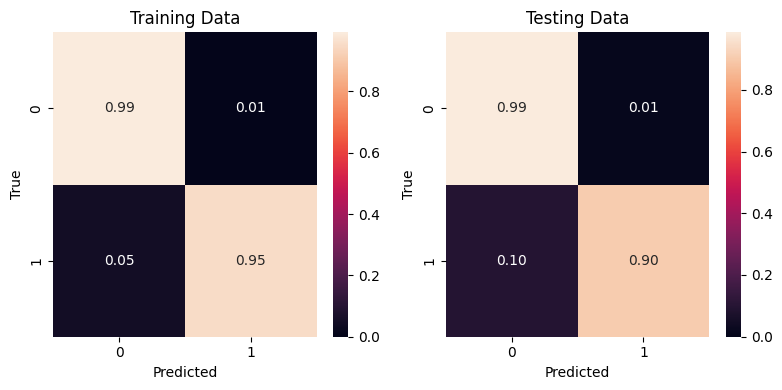

RandomForestClassifier(max_leaf_nodes=3, random_state=42)
              precision    recall  f1-score   support

           0       0.93      0.97      0.95        72
           1       0.95      0.88      0.91        42

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



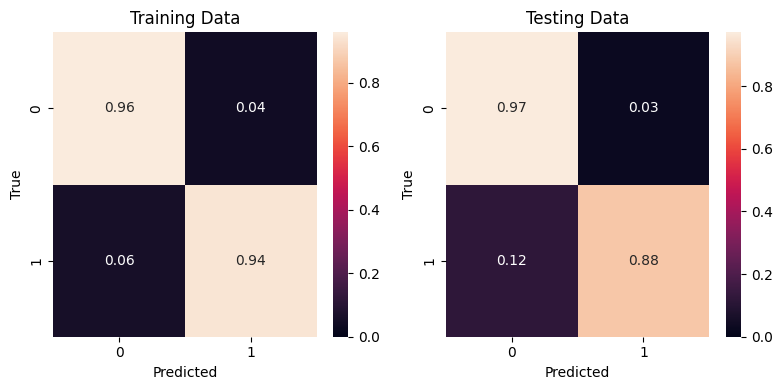

RandomForestClassifier(max_leaf_nodes=10, random_state=42)
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        72
           1       1.00      0.88      0.94        42

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114



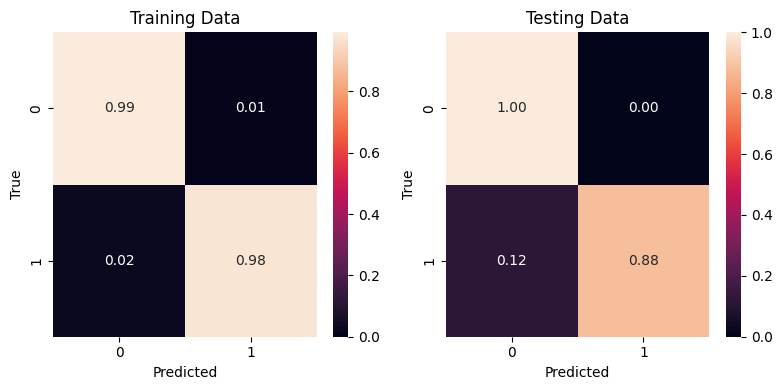

RandomForestClassifier(max_leaf_nodes=30, random_state=42)
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



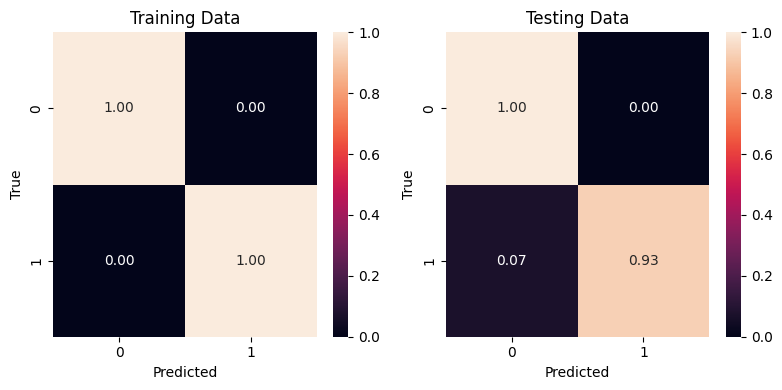

DecisionTreeClassifier(max_leaf_nodes=3, random_state=42)
              precision    recall  f1-score   support

           0       0.93      0.97      0.95        72
           1       0.95      0.88      0.91        42

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



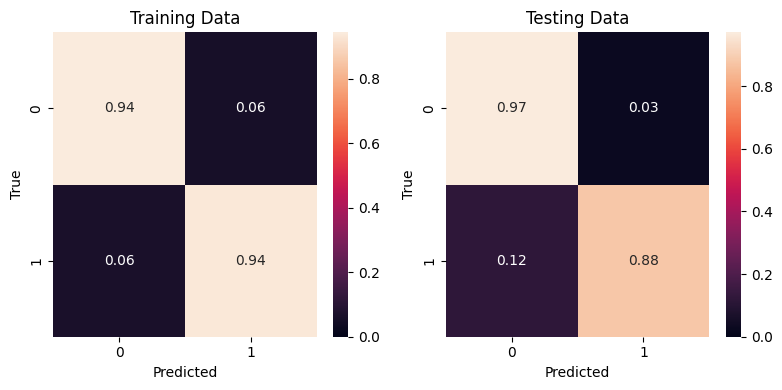

DecisionTreeClassifier(max_leaf_nodes=10, random_state=42)
              precision    recall  f1-score   support

           0       0.92      0.99      0.95        72
           1       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



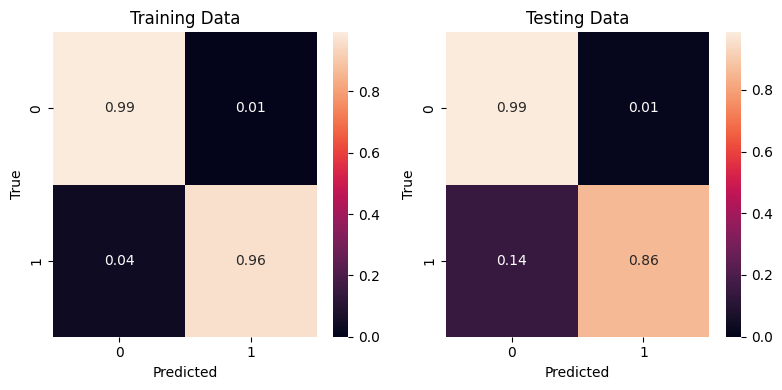

DecisionTreeClassifier(max_leaf_nodes=30, random_state=42)
              precision    recall  f1-score   support

           0       0.93      0.97      0.95        72
           1       0.95      0.88      0.91        42

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



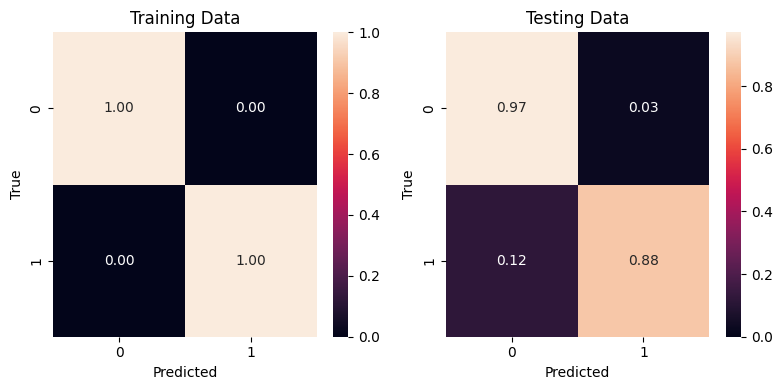

GradientBoostingClassifier(max_leaf_nodes=3, random_state=42)
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



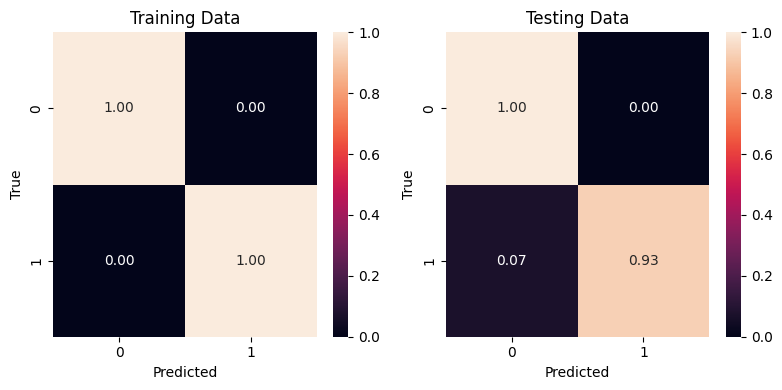

GradientBoostingClassifier(max_leaf_nodes=10, random_state=42)
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



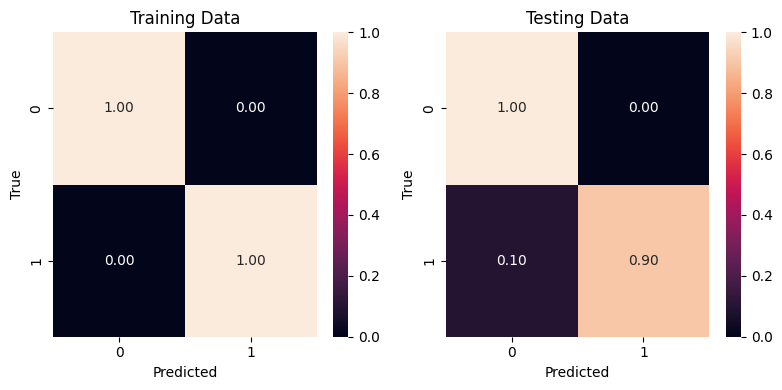

GradientBoostingClassifier(max_leaf_nodes=30, random_state=42)
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



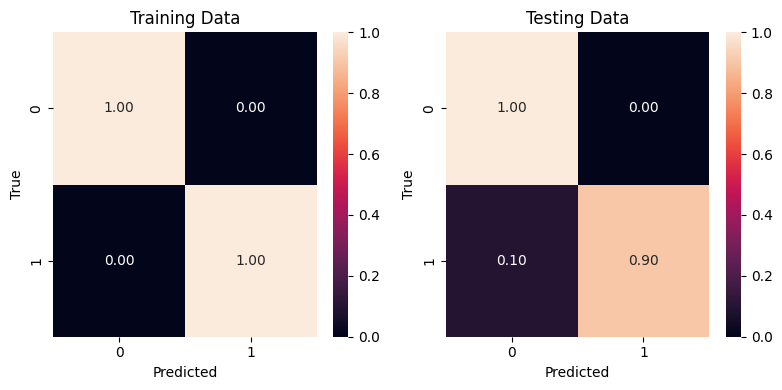

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=3, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        72
           1       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99    

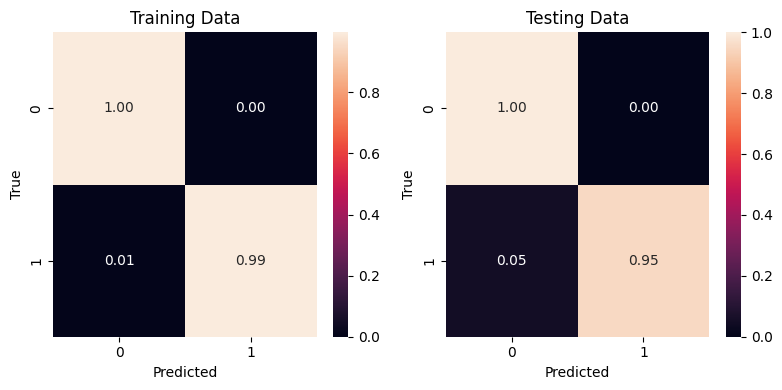

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=10, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98   

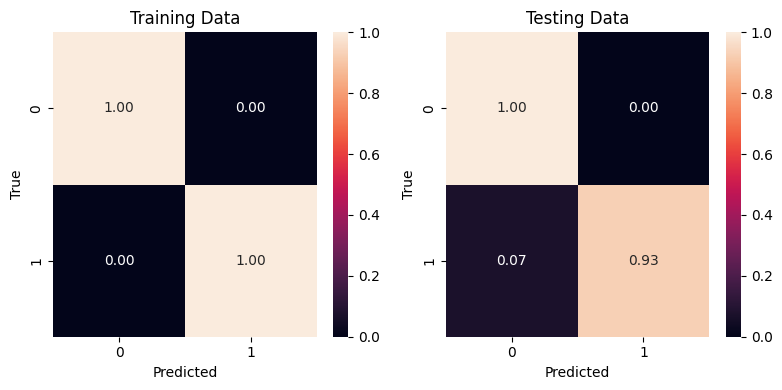

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=30, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98   

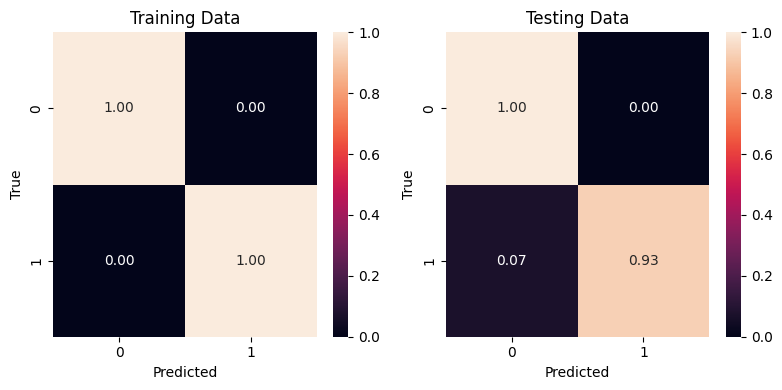

AdaBoostClassifier(learning_rate=0.1, n_estimators=100, random_state=42)
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



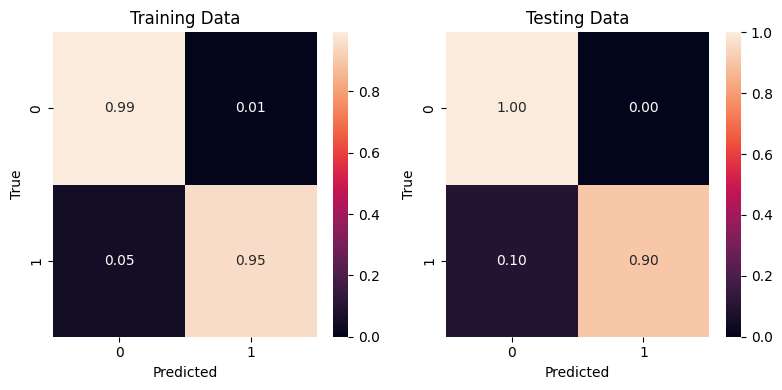

In [69]:
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.pipeline import Pipeline as ImblearnPipeline # Aliasing Pipeline to ImblearnPipeline
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

for m in models:
    # Wrap the model in a pipeline with StandardScaler and SMOTE
    pipe = ImblearnPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(k_neighbors=10, random_state=42)),
        ('clf', m),
    ])

    # Train the pipeline on original X_train, y_train
    pipe.fit(X_train, y_train)

    print(m)

    # Generate predictions using the pipeline
    y_train_pred = pipe.predict(X_train).astype(int) # Use X_train here, as the pipeline handles scaling and SMOTE
    y_test_pred = pipe.predict(X_test).astype(int)   # Use X_test here, as the pipeline handles scaling

    # Print classification report
    print(classification_report(y_test, y_test_pred))

    # Compute confusion matrices
    conf_matrix_train = confusion_matrix(y_train, y_train_pred).astype(float)
    conf_matrix_test = confusion_matrix(y_test, y_test_pred).astype(float)

    # Normalize confusion matrices
    for i in range(conf_matrix_train.shape[0]):
        # Check to avoid division by zero if a row sum is 0
        if conf_matrix_train[i, :].sum() > 0:
            conf_matrix_train[i, :] /= conf_matrix_train[i, :].sum()
        if conf_matrix_test[i, :].sum() > 0:
            conf_matrix_test[i, :] /= conf_matrix_test[i, :].sum()

    # Create subplots for confusion matrices
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))

    # Plot confusion matrix for training data
    sns.heatmap(conf_matrix_train, annot=True, vmin=0, fmt='.2f', ax=axes[0])
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")
    axes[0].set_title("Training Data")

    # Plot confusion matrix for test data
    sns.heatmap(conf_matrix_test, annot=True, vmin=0, fmt='.2f', ax=axes[1])
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")
    axes[1].set_title("Testing Data")

    # Show the plots
    plt.tight_layout()
    plt.show()
# end

# KERAS Cross Validation


==================== Fold 1/10 ====================
Fold 1 — acc: 1.0000  macro-F1: 1.0000  pos-F1: 1.0000

Classification Report (Validation Data):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       1.00      1.00      1.00        17

    accuracy                           1.00        46
   macro avg       1.00      1.00      1.00        46
weighted avg       1.00      1.00      1.00        46



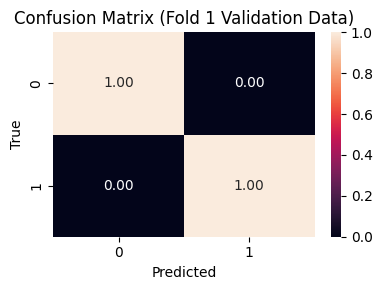


==================== Fold 2/10 ====================


Fold 2 — acc: 0.8478  macro-F1: 0.8238  pos-F1: 0.7586

Classification Report (Validation Data):
              precision    recall  f1-score   support

           0       0.82      0.97      0.89        29
           1       0.92      0.65      0.76        17

    accuracy                           0.85        46
   macro avg       0.87      0.81      0.82        46
weighted avg       0.86      0.85      0.84        46



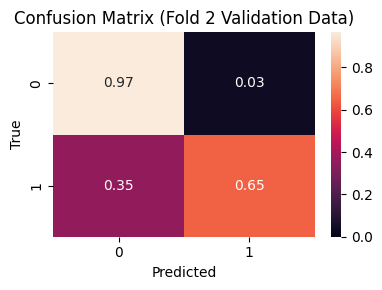


==================== Fold 3/10 ====================
Fold 3 — acc: 0.8696  macro-F1: 0.8673  pos-F1: 0.8500

Classification Report (Validation Data):
              precision    recall  f1-score   support

           0       1.00      0.79      0.88        29
           1       0.74      1.00      0.85        17

    accuracy                           0.87        46
   macro avg       0.87      0.90      0.87        46
weighted avg       0.90      0.87      0.87        46



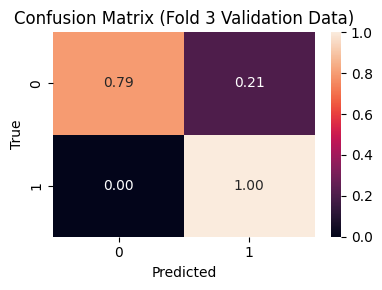


==================== Fold 4/10 ====================
Fold 4 — acc: 1.0000  macro-F1: 1.0000  pos-F1: 1.0000

Classification Report (Validation Data):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       1.00      1.00      1.00        17

    accuracy                           1.00        46
   macro avg       1.00      1.00      1.00        46
weighted avg       1.00      1.00      1.00        46



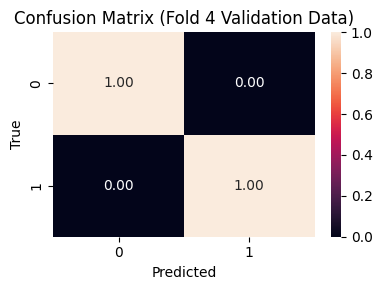


==================== Fold 5/10 ====================
Fold 5 — acc: 0.7826  macro-F1: 0.7822  pos-F1: 0.7727

Classification Report (Validation Data):
              precision    recall  f1-score   support

           0       1.00      0.66      0.79        29
           1       0.63      1.00      0.77        17

    accuracy                           0.78        46
   macro avg       0.81      0.83      0.78        46
weighted avg       0.86      0.78      0.78        46



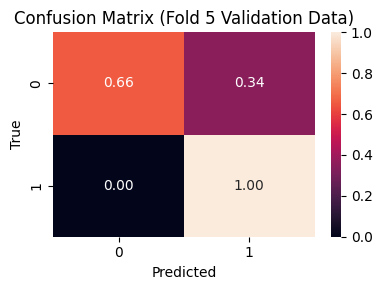


==================== Fold 6/10 ====================
Fold 6 — acc: 0.9556  macro-F1: 0.9527  pos-F1: 0.9412

Classification Report (Validation Data):
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        28
           1       0.94      0.94      0.94        17

    accuracy                           0.96        45
   macro avg       0.95      0.95      0.95        45
weighted avg       0.96      0.96      0.96        45



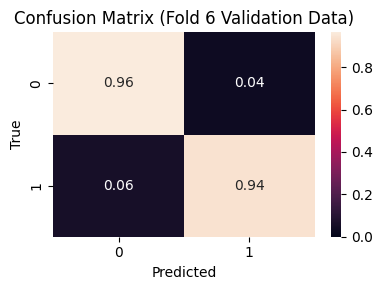


==================== Fold 7/10 ====================
Fold 7 — acc: 0.8222  macro-F1: 0.8109  pos-F1: 0.7647

Classification Report (Validation Data):
              precision    recall  f1-score   support

           0       0.86      0.86      0.86        28
           1       0.76      0.76      0.76        17

    accuracy                           0.82        45
   macro avg       0.81      0.81      0.81        45
weighted avg       0.82      0.82      0.82        45



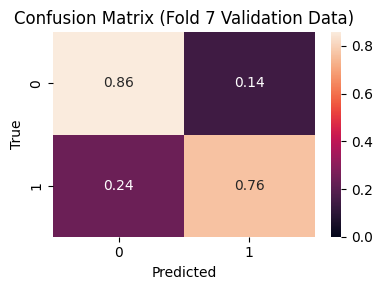


==================== Fold 8/10 ====================
Fold 8 — acc: 0.7333  macro-F1: 0.7332  pos-F1: 0.7391

Classification Report (Validation Data):
              precision    recall  f1-score   support

           0       1.00      0.57      0.73        28
           1       0.59      1.00      0.74        17

    accuracy                           0.73        45
   macro avg       0.79      0.79      0.73        45
weighted avg       0.84      0.73      0.73        45



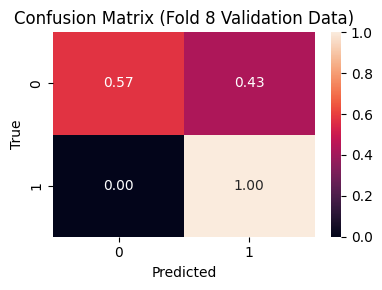


==================== Fold 9/10 ====================
Fold 9 — acc: 0.7556  macro-F1: 0.7551  pos-F1: 0.7442

Classification Report (Validation Data):
              precision    recall  f1-score   support

           0       0.95      0.64      0.77        28
           1       0.62      0.94      0.74        17

    accuracy                           0.76        45
   macro avg       0.78      0.79      0.76        45
weighted avg       0.82      0.76      0.76        45



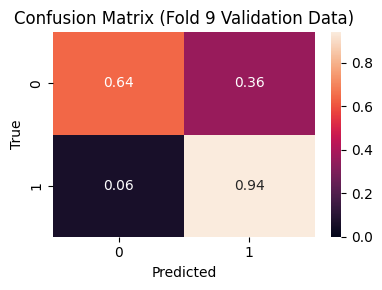


==================== Fold 10/10 ====================
Fold 10 — acc: 0.9111  macro-F1: 0.9030  pos-F1: 0.8750

Classification Report (Validation Data):
              precision    recall  f1-score   support

           0       0.90      0.96      0.93        28
           1       0.93      0.82      0.88        17

    accuracy                           0.91        45
   macro avg       0.92      0.89      0.90        45
weighted avg       0.91      0.91      0.91        45



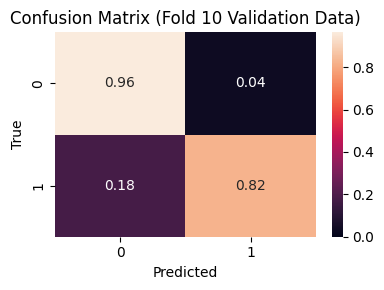


==================== Cross-Validation Summary ====================
Avg Val Accuracy: 0.8678 (±0.0922)
Avg Macro F1:     0.8628 (±0.0930)
Avg Positive F1:  0.8446 (±0.0994)


In [70]:
import tensorflow as tf
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

splits = 10
dropout_rate = 0.1
n_classes = np.unique(y).shape[0]
learning_rate = 0.01

def build_keras_model():
    m = Sequential([
        Input(shape=X.shape[1:]),
        Dense(20, activation='relu'),
        BatchNormalization(),
        Dropout(dropout_rate),
        Dense(20, activation='relu'),
        Dense(20, activation='relu'),
        Dense(n_classes, activation='softmax'),
    ])
    m.compile(optimizer=Adam(learning_rate=learning_rate),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
    return m

early_stopping = EarlyStopping(monitor='val_loss', patience=100,
                               restore_best_weights=True)

# CV runs on X_train / y_train ONLY — X_test is never seen here (no leakage)
kf = StratifiedKFold(n_splits=splits, shuffle=True, random_state=42)
fold_results = []

for fold, (train_index, val_index) in enumerate(kf.split(X_train, y_train)):
    tf.keras.backend.clear_session()
    print(f"\n{'='*20} Fold {fold+1}/{splits} {'='*20}")

    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    scaler_fold = StandardScaler()
    smote_fold  = SMOTE(sampling_strategy='auto', k_neighbors=20, random_state=42)

    X_train_scaled = scaler_fold.fit_transform(X_train_fold)   # fit on fold-train only
    X_val_scaled   = scaler_fold.transform(X_val_fold)         # transform only

    X_train_smoted, y_train_smoted = smote_fold.fit_resample(X_train_scaled, y_train_fold)

    model_cv = build_keras_model()
    history = model_cv.fit(
        X_train_smoted, y_train_smoted,
        epochs=1000, batch_size=256,
        validation_data=(X_val_scaled, y_val_fold),
        callbacks=[early_stopping], verbose=0,
    )

    y_val_pred = np.argmax(model_cv.predict(X_val_scaled, verbose=0), axis=1)
    report_val = classification_report(y_val_fold, y_val_pred,
                                       output_dict=True, zero_division=0)
    fold_results.append({
        'fold': fold + 1,
        'accuracy': report_val['accuracy'],
        'f1_macro': report_val['macro avg']['f1-score'],
        'f1_pos':   report_val['1']['f1-score'],   # binary F1 for fair comparison later
    })
    print(f"Fold {fold+1} — acc: {report_val['accuracy']:.4f}  "
          f"macro-F1: {report_val['macro avg']['f1-score']:.4f}  "
          f"pos-F1: {report_val['1']['f1-score']:.4f}")

    print("\nClassification Report (Validation Data):")
    print(classification_report(y_val_fold, y_val_pred))

    conf_matrix_val = confusion_matrix(y_val_fold, y_val_pred).astype(float)
    # Normalize confusion matrix
    for i in range(conf_matrix_val.shape[0]):
        if conf_matrix_val[i, :].sum() > 0:
            conf_matrix_val[i, :] /= conf_matrix_val[i, :].sum()

    plt.figure(figsize=(4, 3))
    sns.heatmap(conf_matrix_val, annot=True, vmin=0, fmt='.2f')
    plt.title(f'Confusion Matrix (Fold {fold+1} Validation Data)')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

# --- CV summary ---
print(f"\n{'='*20} Cross-Validation Summary {'='*20}")
avg_accuracy = np.mean([r['accuracy'] for r in fold_results])
avg_f1_macro = np.mean([r['f1_macro'] for r in fold_results])
avg_f1_pos   = np.mean([r['f1_pos']   for r in fold_results])
print(f"Avg Val Accuracy: {avg_accuracy:.4f} (±{np.std([r['accuracy'] for r in fold_results]):.4f})")
print(f"Avg Macro F1:     {avg_f1_macro:.4f} (±{np.std([r['f1_macro'] for r in fold_results]):.4f})")
print(f"Avg Positive F1:  {avg_f1_pos:.4f} (±{np.std([r['f1_pos'] for r in fold_results]):.4f})")

# --- Final model: train on ALL of X_train, evaluate ONCE on the held-out X_test ---
tf.keras.backend.clear_session()
final_scaler = StandardScaler()
X_train_final_s = final_scaler.fit_transform(X_train)   # fit on all train
X_test_final_s  = final_scaler.transform(X_test)         # scaler that MATCHES the final model
X_train_final_res, y_train_final_res = SMOTE(
    sampling_strategy='auto', k_neighbors=20, random_state=42
).fit_resample(X_train_final_s, y_train)

X_tr2, X_val2, y_tr2, y_val2 = train_test_split(
    X_train_final_res, y_train_final_res, test_size=0.2,
    stratify=y_train_final_res, random_state=42)

final_keras = build_keras_model()
final_keras.fit(X_tr2, y_tr2, validation_data=(X_val2, y_val2),
                epochs=100, batch_size=256,
                callbacks=[early_stopping], verbose=0)

KERAS CV for reproducibility, analyzing another 10 folds with training andd validation loss curve


==================== Fold 1/10 ====================


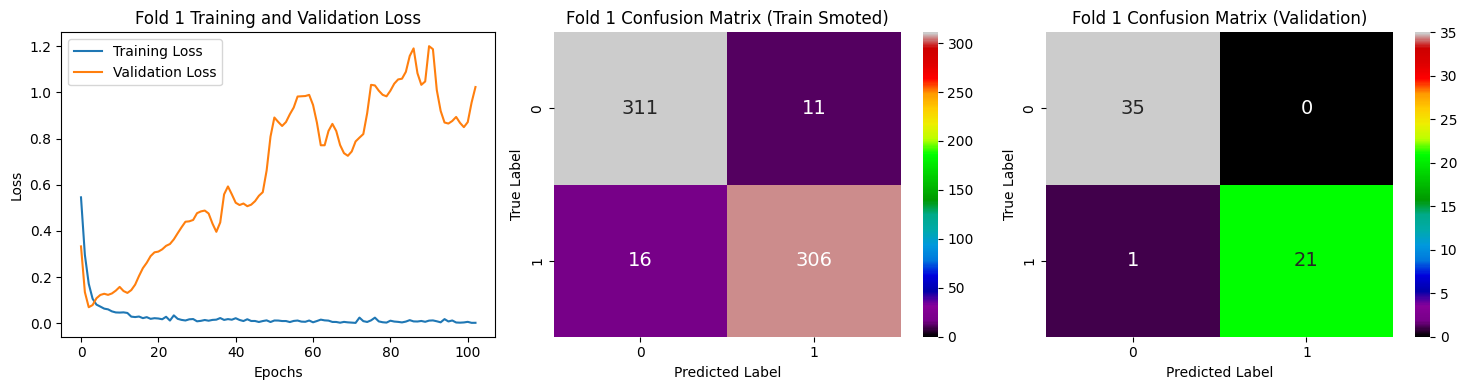

Classification Report (Validation Data - Fold 1):
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        35
           1       1.00      0.95      0.98        22

    accuracy                           0.98        57
   macro avg       0.99      0.98      0.98        57
weighted avg       0.98      0.98      0.98        57


==================== Fold 2/10 ====================


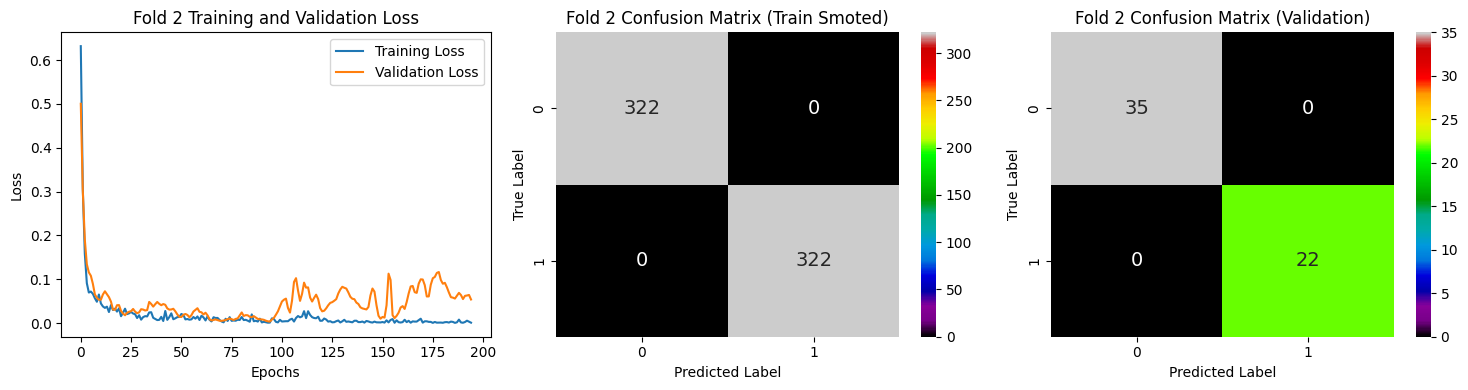

Classification Report (Validation Data - Fold 2):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       1.00      1.00      1.00        22

    accuracy                           1.00        57
   macro avg       1.00      1.00      1.00        57
weighted avg       1.00      1.00      1.00        57


==================== Fold 3/10 ====================


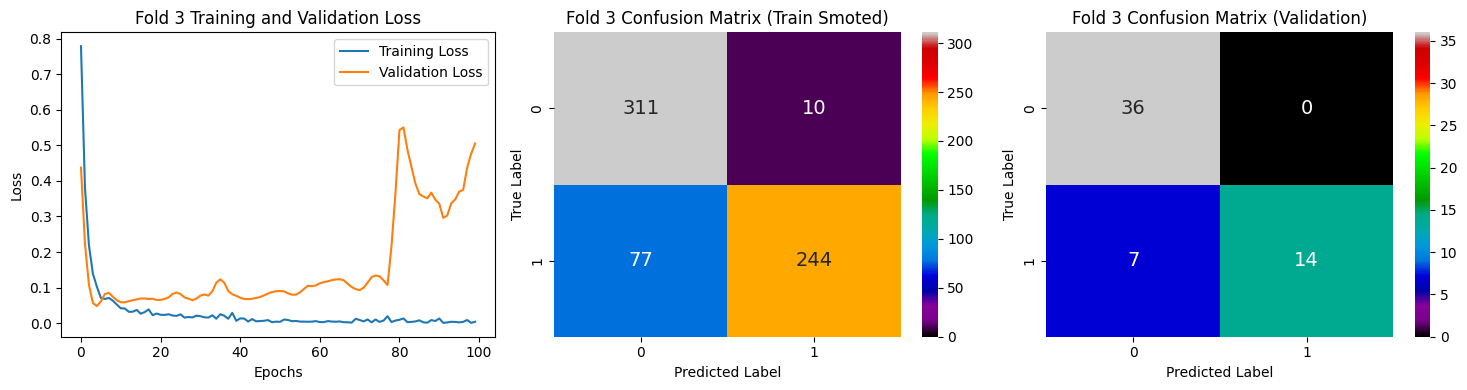

Classification Report (Validation Data - Fold 3):
              precision    recall  f1-score   support

           0       0.84      1.00      0.91        36
           1       1.00      0.67      0.80        21

    accuracy                           0.88        57
   macro avg       0.92      0.83      0.86        57
weighted avg       0.90      0.88      0.87        57


==================== Fold 4/10 ====================


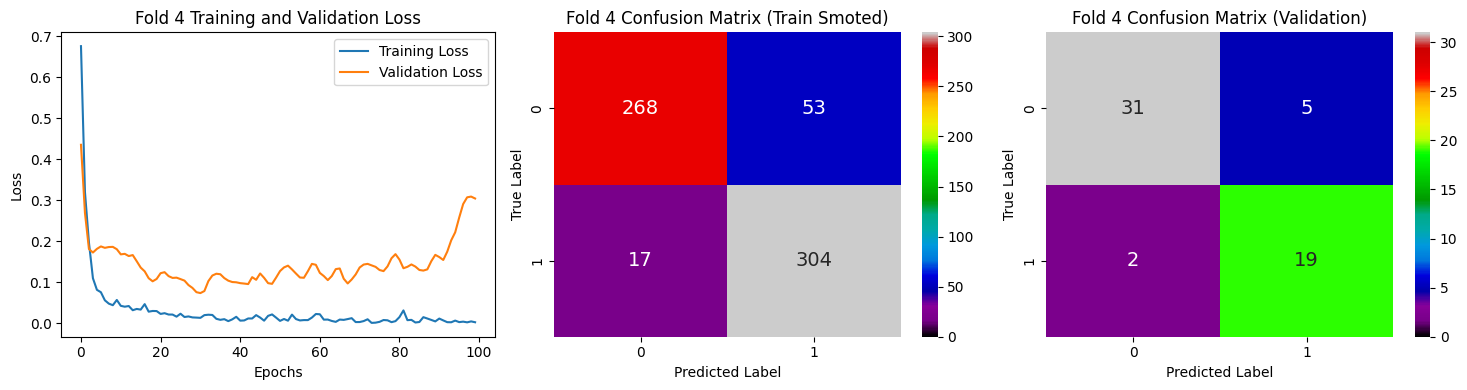

Classification Report (Validation Data - Fold 4):
              precision    recall  f1-score   support

           0       0.94      0.86      0.90        36
           1       0.79      0.90      0.84        21

    accuracy                           0.88        57
   macro avg       0.87      0.88      0.87        57
weighted avg       0.88      0.88      0.88        57


==================== Fold 5/10 ====================


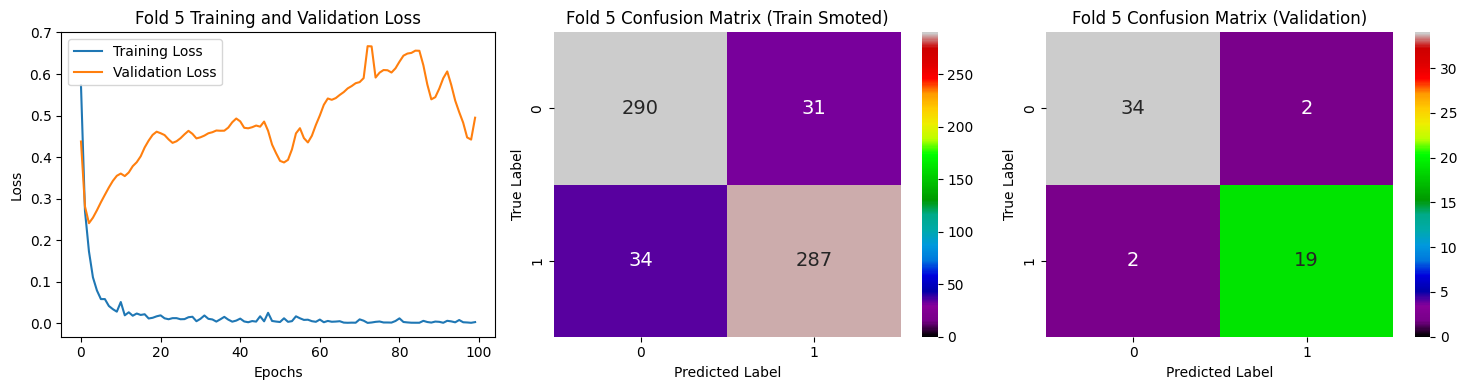

Classification Report (Validation Data - Fold 5):
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        36
           1       0.90      0.90      0.90        21

    accuracy                           0.93        57
   macro avg       0.92      0.92      0.92        57
weighted avg       0.93      0.93      0.93        57


==================== Fold 6/10 ====================


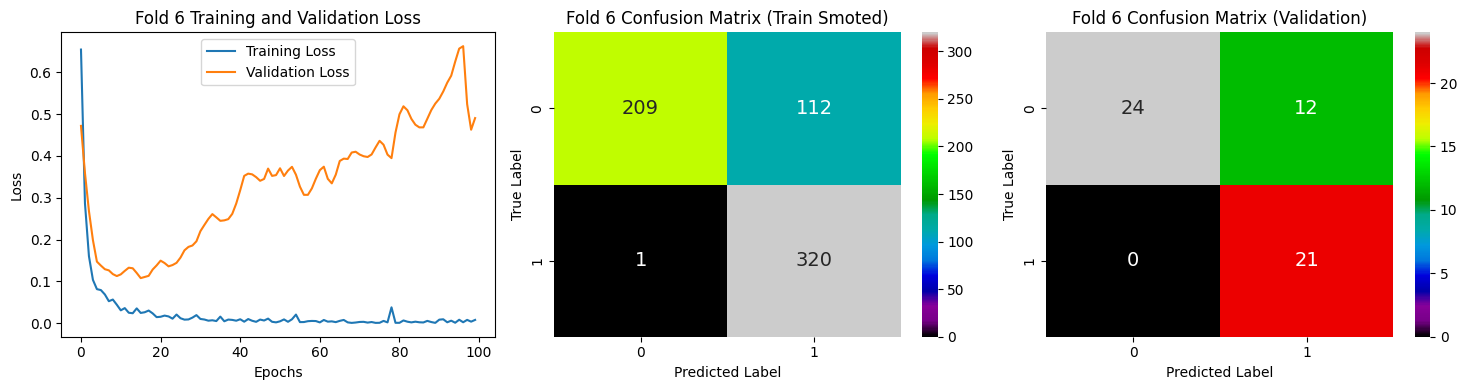

Classification Report (Validation Data - Fold 6):
              precision    recall  f1-score   support

           0       1.00      0.67      0.80        36
           1       0.64      1.00      0.78        21

    accuracy                           0.79        57
   macro avg       0.82      0.83      0.79        57
weighted avg       0.87      0.79      0.79        57


==================== Fold 7/10 ====================


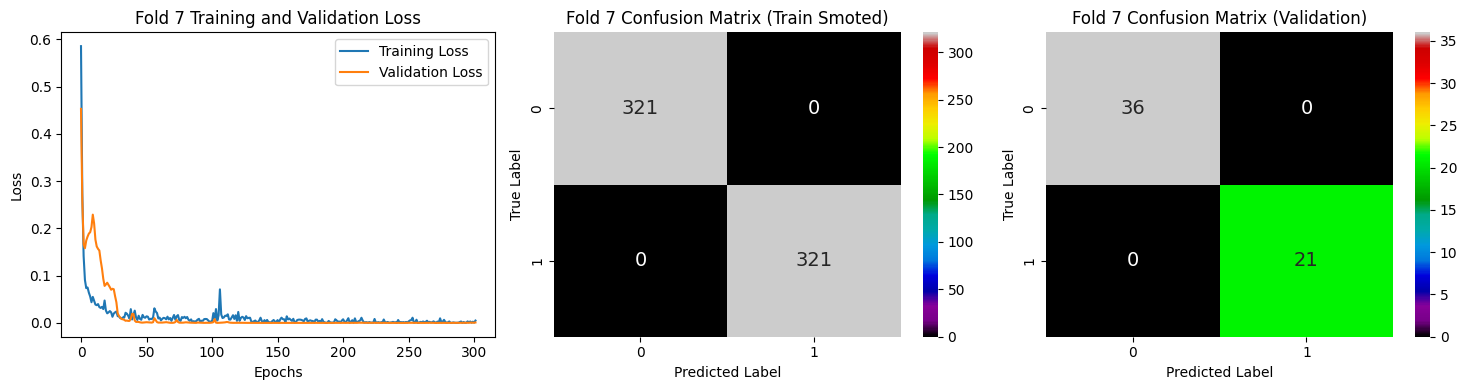

Classification Report (Validation Data - Fold 7):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       1.00      1.00      1.00        21

    accuracy                           1.00        57
   macro avg       1.00      1.00      1.00        57
weighted avg       1.00      1.00      1.00        57


==================== Fold 8/10 ====================


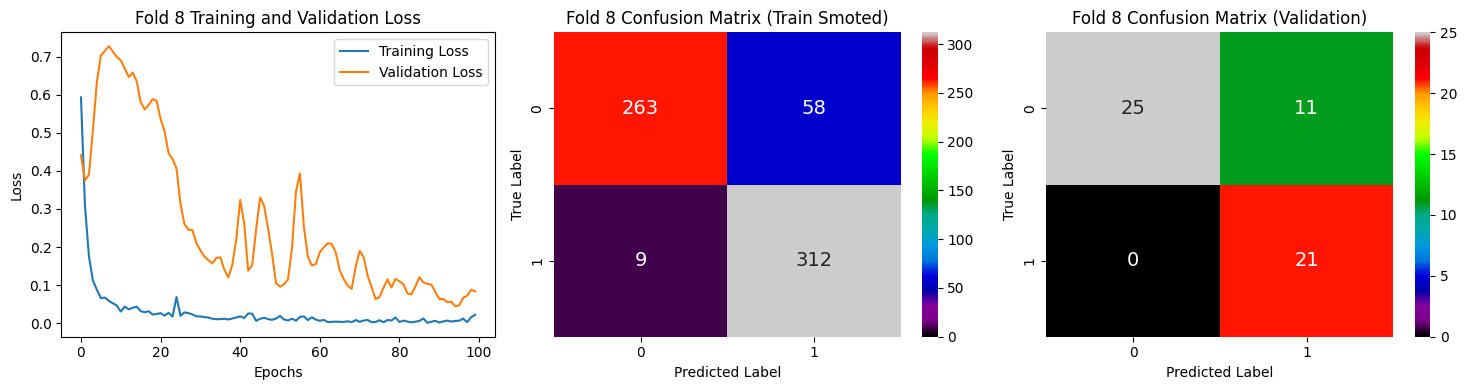

Classification Report (Validation Data - Fold 8):
              precision    recall  f1-score   support

           0       1.00      0.69      0.82        36
           1       0.66      1.00      0.79        21

    accuracy                           0.81        57
   macro avg       0.83      0.85      0.81        57
weighted avg       0.87      0.81      0.81        57


==================== Fold 9/10 ====================


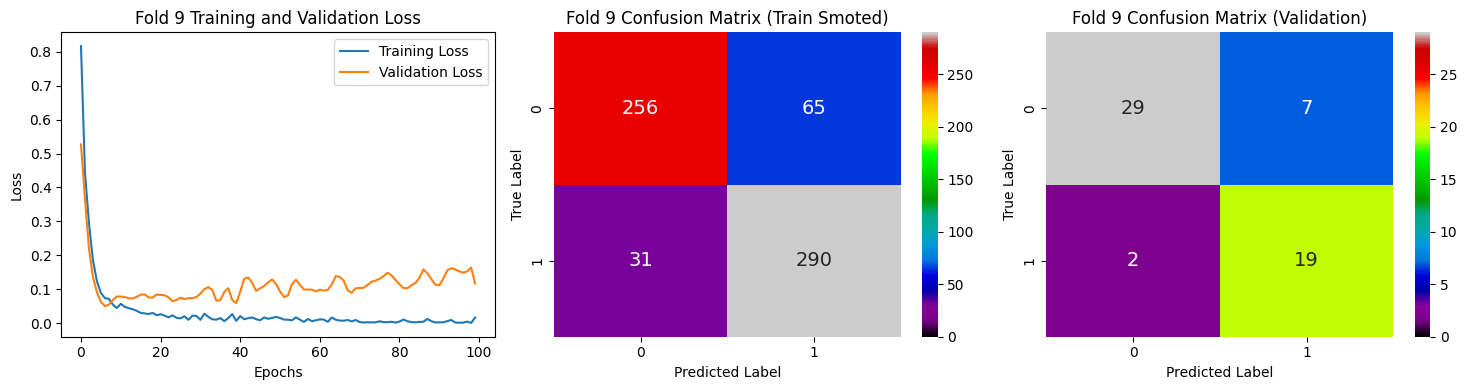

Classification Report (Validation Data - Fold 9):
              precision    recall  f1-score   support

           0       0.94      0.81      0.87        36
           1       0.73      0.90      0.81        21

    accuracy                           0.84        57
   macro avg       0.83      0.86      0.84        57
weighted avg       0.86      0.84      0.84        57


==================== Fold 10/10 ====================


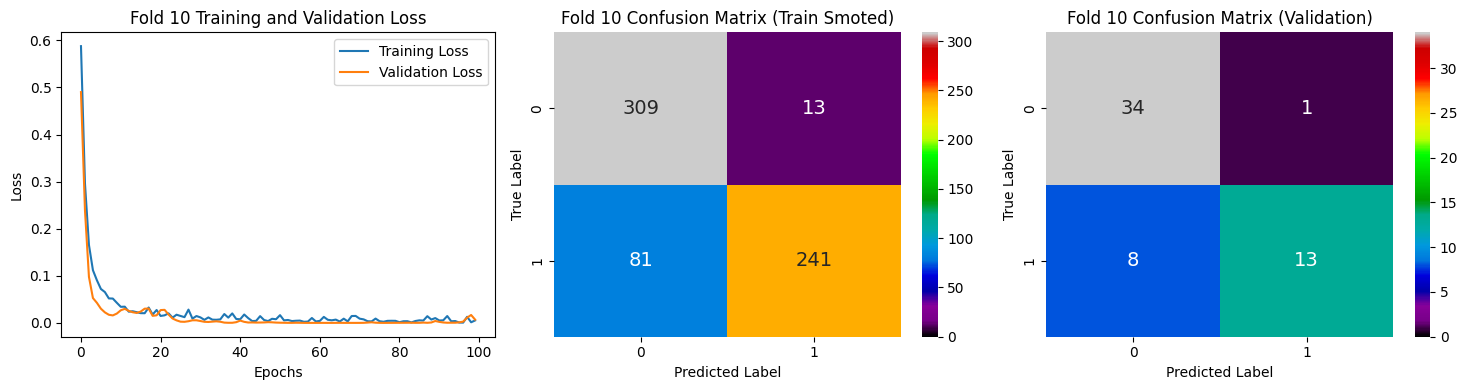

Classification Report (Validation Data - Fold 10):
              precision    recall  f1-score   support

           0       0.81      0.97      0.88        35
           1       0.93      0.62      0.74        21

    accuracy                           0.84        56
   macro avg       0.87      0.80      0.81        56
weighted avg       0.85      0.84      0.83        56


==================== Cross-Validation Summary ====================
Average Validation Accuracy across 10 folds: 0.8945
Average Macro F1-score across 10 folds: 0.8878
Standard Deviation of Validation Accuracy: 0.0750
Standard Deviation of Macro F1-score: 0.0782


In [72]:
import tensorflow as tf
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd # Ensure pandas is imported for .iloc

splits = 10 # Number of folds

dropout_rate = 0.1
n_classes = np.unique(y).shape[0] # Number of unique classes in the target variable

learning_rate = 0.01

# Early stopping callback to prevent overfitting and restore best weights
early_stopping = EarlyStopping(
    monitor='val_loss', # Monitor validation loss
    patience=100,         # Stop if validation loss doesn't improve for 100 epochs
    restore_best_weights=True # Restore the model weights from the epoch with the best validation loss
)

# Initialize Stratified K-Fold to maintain class proportions in each split
kf = StratifiedKFold(n_splits=splits, shuffle=True, random_state=42) # Added random_state for reproducibility

fold_results = [] # List to store results from each fold

# Iterate through each fold generated by StratifiedKFold
for fold, (train_index, val_index) in enumerate(kf.split(X, y)):
    tf.keras.backend.clear_session() # Clear Keras session for a fresh model in each fold

    print(f"\n{'='*20} Fold {fold+1}/{splits} {'='*20}")

    # Split data for the current fold using the indices from StratifiedKFold
    X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
    y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]

    # Initialize StandardScaler and SMOTE for each fold to prevent data leakage
    std_scaler_fold = StandardScaler() # Scales features to have zero mean and unit variance
    smote_fold = SMOTE(sampling_strategy='auto', k_neighbors=20, random_state=42) # Over-samples minority class (k_neighbors=20 from original Keras cell)

    # 1. Scale the data: fit on training data of current fold, then transform both training and validation data
    X_train_scaled = std_scaler_fold.fit_transform(X_train_fold)
    X_val_scaled = std_scaler_fold.transform(X_val_fold)

    # 2. Apply SMOTE only to the *scaled* training data of the current fold to balance classes
    X_train_smoted, y_train_smoted = smote_fold.fit_resample(X_train_scaled, y_train_fold)

    # Build Keras model (architecture identical to cell VmAjjxvZthrC)
    model = Sequential([
        Input(shape=X.shape[1:]), # Input shape is the number of original features (8 in this case)
        Dense(20, activation='relu'), # First hidden layer with ReLU activation
        BatchNormalization(), # Normalizes activations of previous layer
        Dropout(dropout_rate), # Randomly sets a fraction of input units to 0 at each update during training
        Dense(20, activation='relu'), # Second hidden layer with ReLU activation
        Dense(20, activation='relu'), # Third hidden layer with ReLU activation
        Dense(n_classes, activation='softmax'), # Output layer with softmax for multi-class probability distribution
    ])

    # Define the optimizer with a custom learning rate
    optimizer = Adam(learning_rate=learning_rate)

    # Compile model with appropriate loss function and metrics for binary classification
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy', # Appropriate for integer labels (0 or 1) and softmax output
        metrics=['accuracy'] # Monitor accuracy during training
    )

    # Train the model on the SMOTEd and scaled training data
    history = model.fit(
        X_train_smoted, y_train_smoted,
        epochs=1000, # Maximum number of epochs, early stopping will stop training if no improvement
        batch_size=256,
        validation_data=(X_val_scaled, y_val_fold), # Evaluate on scaled validation data
        callbacks=[early_stopping],
        verbose=0, # Set to 0 to suppress output for each epoch, only print fold summary
    )

    # --- Evaluate Model for Current Fold --- (on best weights due to EarlyStopping)
    # Get predictions for training and validation data
    y_train_pred_probs = model.predict(X_train_smoted, verbose=0)
    y_train_pred = np.argmax(y_train_pred_probs, axis=1)

    y_val_pred_probs = model.predict(X_val_scaled, verbose=0)
    y_val_pred  = np.argmax(y_val_pred_probs, axis=1)

    # Compute confusion matrices for both training and validation sets
    cm_train = confusion_matrix(y_train_smoted, y_train_pred)
    cm_val = confusion_matrix(y_val_fold, y_val_pred)

    # Generate classification report for validation data to get detailed metrics
    report_val = classification_report(y_val_fold, y_val_pred, output_dict=True, zero_division=0)
    fold_accuracy = report_val['accuracy']
    fold_f1_macro = report_val['macro avg']['f1-score']

    # Store results for this fold
    fold_results.append({
        'fold': fold + 1,
        'accuracy': fold_accuracy,
        'f1_macro': fold_f1_macro,
        'train_history': history,
        'cm_train': cm_train,
        'cm_val': cm_val,
        'report_val': report_val
    })

    # Plot results for this individual fold
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Left subplot: Training and Validation Loss over epochs
    axes[0].plot(history.history['loss'], label='Training Loss')
    axes[0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0].set_title(f'Fold {fold+1} Training and Validation Loss')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    # Middle subplot: Confusion Matrix for the SMOTEd training data
    sns.heatmap(cm_train, annot=True, fmt='d', ax=axes[1], vmin=0, annot_kws={"size": 14}, cmap='nipy_spectral')
    axes[1].set_title(f'Fold {fold+1} Confusion Matrix (Train Smoted)')
    axes[1].set_xlabel('Predicted Label')
    axes[1].set_ylabel('True Label')

    # Right subplot: Confusion Matrix for the validation data of the current fold
    sns.heatmap(cm_val, annot=True, fmt='d', ax=axes[2], vmin=0, annot_kws={"size": 14}, cmap='nipy_spectral')
    axes[2].set_title(f'Fold {fold+1} Confusion Matrix (Validation)')
    axes[2].set_xlabel('Predicted Label')
    axes[2].set_ylabel('True Label')

    plt.tight_layout()
    plt.show()

    print(f"Classification Report (Validation Data - Fold {fold+1}):")
    print(classification_report(y_val_fold, y_val_pred, zero_division=0))

# --- Summarize all folds after the loop completes ---
print(f"\n{'='*20} Cross-Validation Summary {'='*20}")
# Calculate average accuracy and F1-score across all folds
avg_accuracy = np.mean([res['accuracy'] for res in fold_results])
avg_f1_macro = np.mean([res['f1_macro'] for res in fold_results])
print(f"Average Validation Accuracy across {splits} folds: {avg_accuracy:.4f}")
print(f"Average Macro F1-score across {splits} folds: {avg_f1_macro:.4f}")

# Optional: Display standard deviation for a better understanding of variability
std_accuracy = np.std([res['accuracy'] for res in fold_results])
std_f1_macro = np.std([res['f1_macro'] for res in fold_results])
print(f"Standard Deviation of Validation Accuracy: {std_accuracy:.4f}")
print(f"Standard Deviation of Macro F1-score: {std_f1_macro:.4f}")

# --- Final model: train on ALL of X_train, evaluate ONCE on the held-out X_test ---
tf.keras.backend.clear_session()
final_scaler = StandardScaler()
X_train_final_s = final_scaler.fit_transform(X_train)   # fit on all train
X_test_final_s  = final_scaler.transform(X_test)         # scaler that MATCHES the final model
X_train_final_res, y_train_final_res = SMOTE(
    sampling_strategy='auto', k_neighbors=20, random_state=42
).fit_resample(X_train_final_s, y_train)

X_tr2, X_val2, y_tr2, y_val2 = train_test_split(
    X_train_final_res, y_train_final_res, test_size=0.2,
    stratify=y_train_final_res, random_state=42)

final_keras = build_keras_model()
final_keras.fit(X_tr2, y_tr2, validation_data=(X_val2, y_val2),
                epochs=100, batch_size=256,
                callbacks=[early_stopping], verbose=0)

Comparison: Keras CV vs. Traditional ML Models

In [73]:
from sklearn.metrics import average_precision_score, roc_auc_score

# Get predicted probabilities for the positive class (class 1) from the Keras model on the scaled test data
y_keras_prob = model.predict(X_test_s)[:, 1]

# Calculate AUPRC for the Keras model
keras_auprc = average_precision_score(y_test, y_keras_prob)

# Calculate AUROC for the Keras model
keras_auroc = roc_auc_score(y_test, y_keras_prob)

print(f"Keras Model AUPRC on Test Set: {keras_auprc:.4f}")
print(f"Keras Model AUROC on Test Set: {keras_auroc:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Keras Model AUPRC on Test Set: 0.9466
Keras Model AUROC on Test Set: 0.9587


In [74]:
from sklearn.metrics import matthews_corrcoef

y_keras_pred = model.predict(X_test_s).argmax(axis=1)
keras_mcc = matthews_corrcoef(y_test, y_keras_pred)

print(f"Keras Model MCC on Test Set: {keras_mcc:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Keras Model MCC on Test Set: 0.7741


In [76]:
keras_cv_metrics = {
    'Model': 'Keras CV (Avg over 10 folds)',
    'AUPRC': keras_auprc,
    'AUROC': keras_auroc,
    'MCC': keras_mcc,   # Updated to use the calculated MCC
    'F1': avg_f1_macro,
    'Accuracy': avg_accuracy # Adding accuracy for completeness
}

# Convert to DataFrame
keras_cv_df = pd.DataFrame([keras_cv_metrics])

# Ensure results_df has an 'Accuracy' column for consistent concatenation.
# For existing models, if 'Accuracy' is not present, it would be good to add it,
# but for this comparison, we'll assume the primary comparison is F1 and AUPRC.
# We'll just add accuracy to the Keras row for now.

# Assuming results_df from cell _p8_7dJ_qy2d is available
# If results_df doesn't have an 'Accuracy' column from previous runs, we'll create it with NaNs
if 'Accuracy' not in results_df.columns:
    results_df['Accuracy'] = np.nan

# Select and reorder columns for concatenation to match `keras_cv_df`
# Only keep common columns and F1, AUPRC, AUROC, MCC for main comparison
common_cols = ['Model', 'AUPRC', 'AUROC', 'MCC', 'F1']
combined_df = pd.concat([results_df[common_cols], keras_cv_df[common_cols]], ignore_index=True)

print("\n=== Combined Model Comparison (Keras CV vs. Traditional ML, sorted by F1) ===")
# Sort by F1-score for a clear comparison
display(combined_df.sort_values('F1', ascending=False).reset_index(drop=True).fillna('N/A'))


=== Combined Model Comparison (Keras CV vs. Traditional ML, sorted by F1) ===


,Model,AUPRC,AUROC,MCC,F1
0,XGBClassifier(leaves=3),0.992320,0.993386,0.962622,0.975610
1,LogisticRegression(leaves=N/A),0.994854,0.996362,0.943340,0.963855
2,RandomForestClassifier(leaves=30),0.994679,0.996693,0.944155,0.962963
3,GradientBoostingClassifier(leaves=3),0.996822,0.998016,0.944155,0.962963
4,XGBClassifier(leaves=30),0.995083,0.996693,0.944155,0.962963
5,XGBClassifier(leaves=10),0.995491,0.997024,0.944155,0.962963
6,GradientBoostingClassifier(leaves=30),0.996670,0.998016,0.925820,0.950000
7,GradientBoostingClassifier(leaves=10),0.996670,0.998016,0.925820,0.950000
8,AdaBoostClassifier(leaves=N/A),0.994372,0.995701,0.925820,0.950000
9,KNeighborsClassifier(leaves=N/A),0.976721,0.982143,0.905824,0.938272
